Import Bilbiotek i wczytanie pliku


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px


In [2]:
base_path = r"C:\Users\ariel\Documents\Kurs Data Science\projekty\Projekt Grupowy - Predykcja popytu na produkty\jdszr23-grupa-3\projekt_grupowy\dane"

In [3]:
orders = pd.read_csv(f"{base_path}\\olist_orders_dataset.csv")
order_items = pd.read_csv(f"{base_path}\\olist_order_items_dataset.csv")
products = pd.read_csv(f"{base_path}\\olist_products_dataset.csv")
category_translation = pd.read_csv(f"{base_path}\\product_category_name_translation.csv")

Wyświetlenie Danych Wstępna Eksploracja danych 

In [4]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [5]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [6]:
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [7]:
category_translation.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


Wyświetlenie Rozmiaru Danych , Typów danych oraz Braków i duplikatów

In [8]:
print("orders:", orders.shape)
print("order_items:", order_items.shape)
print("products:", products.shape)
print("category_translation:", category_translation.shape)

orders: (99441, 8)
order_items: (112650, 7)
products: (32951, 9)
category_translation: (71, 2)


In [9]:
orders.dtypes

order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object

In [10]:
order_items.dtypes

order_id                object
order_item_id            int64
product_id              object
seller_id               object
shipping_limit_date     object
price                  float64
freight_value          float64
dtype: object

In [11]:
products.dtypes

product_id                     object
product_category_name          object
product_name_lenght           float64
product_description_lenght    float64
product_photos_qty            float64
product_weight_g              float64
product_length_cm             float64
product_height_cm             float64
product_width_cm              float64
dtype: object

In [12]:
category_translation.dtypes

product_category_name            object
product_category_name_english    object
dtype: object

In [13]:
orders.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [14]:
order_items.isnull().sum()

order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

In [15]:
products.isnull().sum()

product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

In [16]:
category_translation.isnull().sum()

product_category_name            0
product_category_name_english    0
dtype: int64

In [17]:
orders.duplicated().sum()

np.int64(0)

In [18]:
order_items.duplicated().sum()

np.int64(0)

In [19]:
products.duplicated().sum()

np.int64(0)

In [20]:
category_translation.duplicated().sum()

np.int64(0)

Wartości unikalne 

In [21]:
orders["order_id"].nunique(), len(orders)

(99441, 99441)

In [22]:
products["product_id"].nunique(), len(products)

(32951, 32951)

In [23]:
category_translation["product_category_name"].nunique(), len(category_translation)

(71, 71)

Merge Danych, aby uzyskać pełny zestaw danych do analizy oraz ich sprawdzenie : 

In [24]:
sales_base = order_items.merge(
    orders,
    on="order_id",
    how="left"
)

In [25]:
sales_base.shape

(112650, 14)

In [26]:
order_items.shape[0], sales_base.shape[0]

(112650, 112650)

In [27]:
sales_base = sales_base.merge(
    products,
    on="product_id",
    how="left"
)

In [28]:
sales_base = sales_base.merge(
    category_translation,
    on="product_category_name",
    how="left"
)

In [29]:
sales_base.shape

(112650, 23)

In [30]:
sales_base.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,...,order_estimated_delivery_date,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,...,2017-09-29 00:00:00,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,...,2017-05-15 00:00:00,pet_shop,56.0,239.0,2.0,30000.0,50.0,30.0,40.0,pet_shop
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,...,2018-02-05 00:00:00,moveis_decoracao,59.0,695.0,2.0,3050.0,33.0,13.0,33.0,furniture_decor
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,...,2018-08-20 00:00:00,perfumaria,42.0,480.0,1.0,200.0,16.0,10.0,15.0,perfumery
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,...,2017-03-17 00:00:00,ferramentas_jardim,59.0,409.0,1.0,3750.0,35.0,40.0,30.0,garden_tools


In [31]:
sales_base.isnull().sum().sort_values(ascending=False).head(20)

order_delivered_customer_date    2454
product_category_name_english    1627
product_photos_qty               1603
product_description_lenght       1603
product_name_lenght              1603
product_category_name            1603
order_delivered_carrier_date     1194
product_weight_g                   18
product_length_cm                  18
product_height_cm                  18
product_width_cm                   18
order_approved_at                  15
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_item_id                       0
freight_value                       0
order_estimated_delivery_date       0
price                               0
shipping_limit_date                 0
dtype: int64

In [32]:
sales_base.columns.tolist()

['order_id',
 'order_item_id',
 'product_id',
 'seller_id',
 'shipping_limit_date',
 'price',
 'freight_value',
 'customer_id',
 'order_status',
 'order_purchase_timestamp',
 'order_approved_at',
 'order_delivered_carrier_date',
 'order_delivered_customer_date',
 'order_estimated_delivery_date',
 'product_category_name',
 'product_name_lenght',
 'product_description_lenght',
 'product_photos_qty',
 'product_weight_g',
 'product_length_cm',
 'product_height_cm',
 'product_width_cm',
 'product_category_name_english']

Filtrowanie Danych 

In [33]:
sales_base["order_status"].value_counts(dropna=False)

order_status
delivered      110197
shipped          1185
canceled          542
invoiced          359
processing        357
unavailable         7
approved            3
Name: count, dtype: int64

Pogłębienie EDA , kopia danych  , podgląd kolumn 

In [34]:
df = sales_base.copy()

In [35]:
df.columns.tolist()

['order_id',
 'order_item_id',
 'product_id',
 'seller_id',
 'shipping_limit_date',
 'price',
 'freight_value',
 'customer_id',
 'order_status',
 'order_purchase_timestamp',
 'order_approved_at',
 'order_delivered_carrier_date',
 'order_delivered_customer_date',
 'order_estimated_delivery_date',
 'product_category_name',
 'product_name_lenght',
 'product_description_lenght',
 'product_photos_qty',
 'product_weight_g',
 'product_length_cm',
 'product_height_cm',
 'product_width_cm',
 'product_category_name_english']

konwersja kolumn dat na datetime

In [36]:
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_columns:
    df[col] = pd.to_datetime(df[col], errors="coerce")

kontrola i sprawdzenie danych po konwersji 

In [37]:
df[date_columns].dtypes

order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object

In [38]:
df[date_columns].isnull().sum()

order_purchase_timestamp            0
order_approved_at                  15
order_delivered_carrier_date     1194
order_delivered_customer_date    2454
order_estimated_delivery_date       0
dtype: int64

 analiza statusów zamówień

In [39]:
df["order_status"].value_counts(dropna=False)

order_status
delivered      110197
shipped          1185
canceled          542
invoiced          359
processing        357
unavailable         7
approved            3
Name: count, dtype: int64

udział procentowy statusów

In [40]:
status_counts = df["order_status"].value_counts(dropna=False)
status_share = (status_counts / len(df) * 100).round(2)
status_share

order_status
delivered      97.82
shipped         1.05
canceled        0.48
invoiced        0.32
processing      0.32
unavailable     0.01
approved        0.00
Name: count, dtype: float64

Analiza Dostaw - mają wpływ na cene a co za tym idzie na zamówienia 

In [41]:
delivered_df = df[df["order_status"] == "delivered"].copy()

In [42]:
print("Wszystkie rekordy:", len(df))
print("Delivered:", len(delivered_df))
print("Udział delivered (%):", round(len(delivered_df) / len(df) * 100, 2))

Wszystkie rekordy: 112650
Delivered: 110197
Udział delivered (%): 97.82


In [43]:
delivered_df[
    ["order_purchase_timestamp", "order_delivered_customer_date", "order_estimated_delivery_date"]
].isnull().sum()

order_purchase_timestamp         0
order_delivered_customer_date    8
order_estimated_delivery_date    0
dtype: int64

In [44]:
delivered_df["delivery_days"] = (
    delivered_df["order_delivered_customer_date"] - delivered_df["order_purchase_timestamp"]
).dt.days

In [45]:
delivered_df["delivery_vs_estimate_days"] = (
    delivered_df["order_delivered_customer_date"] - delivered_df["order_estimated_delivery_date"]
).dt.days

In [46]:
delivered_df["delivery_days"].describe()

count    110189.000000
mean         12.007342
std           9.451153
min           0.000000
25%           6.000000
50%          10.000000
75%          15.000000
max         209.000000
Name: delivery_days, dtype: float64

In [47]:
delivered_df["delivery_vs_estimate_days"].describe()

count    110189.000000
mean        -12.029041
std          10.158194
min        -147.000000
25%         -17.000000
50%         -13.000000
75%          -7.000000
max         188.000000
Name: delivery_vs_estimate_days, dtype: float64

In [48]:
delivered_df[delivered_df["delivery_days"] < 0][
    ["order_id", "order_purchase_timestamp", "order_delivered_customer_date", "delivery_days"]
].head()

,order_id,order_purchase_timestamp,order_delivered_customer_date,delivery_days


In [49]:
delivered_df["price"].describe()

count    110197.000000
mean        119.980563
std         182.299446
min           0.850000
25%          39.900000
50%          74.900000
75%         134.170000
max        6735.000000
Name: price, dtype: float64

In [50]:
delivered_df["freight_value"].describe()

count    110197.000000
mean         19.948598
std          15.698136
min           0.000000
25%          13.080000
50%          16.260000
75%          21.150000
max         409.680000
Name: freight_value, dtype: float64

Rozkłąd cen przez percentyle 

In [51]:
delivered_df["price"].quantile([0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])

0.01      9.990
0.05     17.000
0.25     39.900
0.50     74.900
0.75    134.170
0.95    349.000
0.99    887.076
Name: price, dtype: float64

ile mamy braków kategorii po filtrze 

In [52]:
delivered_df["product_category_name_english"].isnull().sum()

np.int64(1559)

top kategorie sprzedażowe po ilości 

In [53]:
delivered_df["product_category_name_english"].value_counts().head(15)

product_category_name_english
bed_bath_table           10953
health_beauty             9465
sports_leisure            8431
furniture_decor           8160
computers_accessories     7644
housewares                6795
watches_gifts             5859
telephony                 4430
garden_tools              4268
auto                      4140
toys                      4030
cool_stuff                3718
perfumery                 3340
baby                      2982
electronics               2729
Name: count, dtype: int64

top kategorie po przychodzie 

In [54]:
revenue_by_category = (
    delivered_df.groupby("product_category_name_english")["price"]
    .sum()
    .sort_values(ascending=False)
)

revenue_by_category.head(15)

product_category_name_english
health_beauty            1233131.72
watches_gifts            1166176.98
bed_bath_table           1023434.76
sports_leisure            954852.55
computers_accessories     888724.61
furniture_decor           711927.69
housewares                615628.69
cool_stuff                610204.10
auto                      578966.65
toys                      471286.48
garden_tools              470495.28
baby                      400421.84
perfumery                 390144.65
telephony                 309860.23
office_furniture          268154.31
Name: price, dtype: float64

 przygotowanie daty zakupu do agregacji

In [55]:
delivered_df["purchase_date"] = delivered_df["order_purchase_timestamp"].dt.date
delivered_df["purchase_month"] = delivered_df["order_purchase_timestamp"].dt.to_period("M")
delivered_df["purchase_week"] = delivered_df["order_purchase_timestamp"].dt.to_period("W")

sprzedaż miesięczna: liczba pozycji

In [56]:
monthly_units = (
    delivered_df.groupby("purchase_month")
    .size()
    .reset_index(name="units_sold")
)

monthly_units.head()

,purchase_month,units_sold
0,2016-09,3
1,2016-10,313
2,2016-12,1
3,2017-01,913
4,2017-02,1858


 sprzedaż miesięczna: przychód

In [57]:
monthly_revenue = (
    delivered_df.groupby("purchase_month")["price"]
    .sum()
    .reset_index(name="revenue")
)

monthly_revenue.head()

,purchase_month,revenue
0,2016-09,134.97
1,2016-10,40325.11
2,2016-12,10.90
3,2017-01,111798.36
4,2017-02,234223.40


zakres czasu 

In [58]:
print("Pierwsza data zakupu:", delivered_df["order_purchase_timestamp"].min())
print("Ostatnia data zakupu:", delivered_df["order_purchase_timestamp"].max())

Pierwsza data zakupu: 2016-09-15 12:16:38
Ostatnia data zakupu: 2018-08-29 15:00:37


liczba unikalnych kategorii po filtrze 

In [59]:
delivered_df["product_category_name_english"].nunique()

71

In [60]:
delivered_df["product_id"].nunique()

32216

ile rekordów ma każda kategoria 

In [61]:
category_counts = delivered_df["product_category_name_english"].value_counts()
category_counts.describe()

count       71.000000
mean      1530.112676
std       2553.036056
min          2.000000
25%         93.000000
50%        274.000000
75%       1796.000000
max      10953.000000
Name: count, dtype: float64

top 10 kategorii 

In [62]:
top_10_categories = delivered_df["product_category_name_english"].value_counts().head(10).index.tolist()
top_10_categories

['bed_bath_table',
 'health_beauty',
 'sports_leisure',
 'furniture_decor',
 'computers_accessories',
 'housewares',
 'watches_gifts',
 'telephony',
 'garden_tools',
 'auto']

WIzualizacja danych 

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10

In [64]:
print("Liczba rekordów:", delivered_df.shape[0])
print("Liczba kolumn:", delivered_df.shape[1])

display(
    delivered_df[
        [
            "order_id",
            "product_id",
            "product_category_name_english",
            "price",
            "freight_value",
            "order_purchase_timestamp",
            "delivery_days",
            "delivery_vs_estimate_days"
        ]
    ].head()
)

Liczba rekordów: 110197
Liczba kolumn: 28


,order_id,product_id,product_category_name_english,price,freight_value,order_purchase_timestamp,delivery_days,delivery_vs_estimate_days
0,00010242fe8c5a6d1ba2dd792cb16214,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,58.90,13.29,2017-09-13 08:59:02,7.0,-9.0
1,00018f77f2f0320c557190d7a144bdd3,e5f2d52b802189ee658865ca93d83a8f,pet_shop,239.90,19.93,2017-04-26 10:53:06,16.0,-3.0
2,000229ec398224ef6ca0657da4fc703e,c777355d18b72b67abbeef9df44fd0fd,furniture_decor,199.00,17.87,2018-01-14 14:33:31,7.0,-14.0
3,00024acbcdf0a6daa1e931b038114c75,7634da152a4610f1595efa32f14722fc,perfumery,12.99,12.79,2018-08-08 10:00:35,6.0,-6.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,ac6c3623068f30de03045865e4e10089,garden_tools,199.90,18.14,2017-02-04 13:57:51,25.0,-16.0


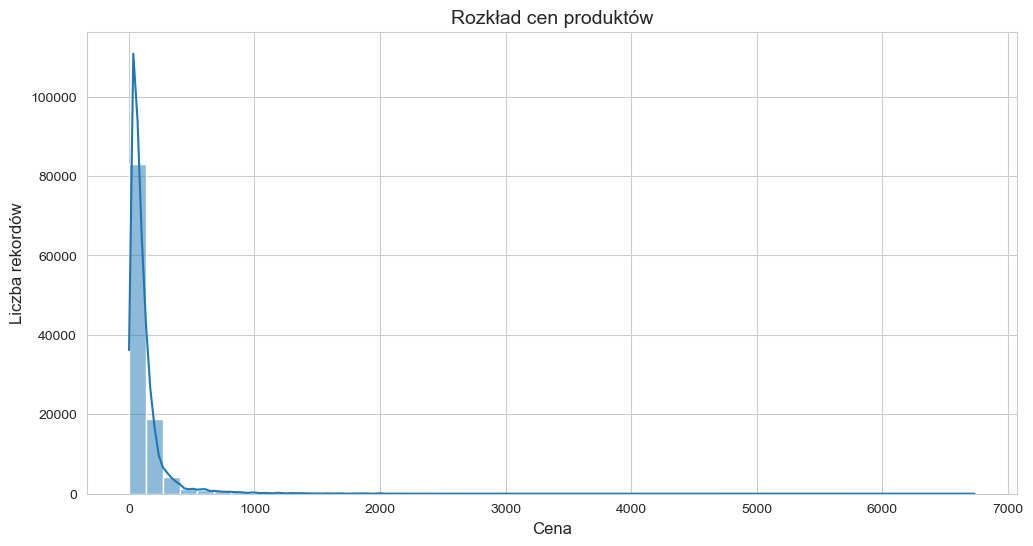

In [65]:
plt.figure(figsize=(12, 6))
sns.histplot(delivered_df["price"], bins=50, kde=True)

plt.title("Rozkład cen produktów")
plt.xlabel("Cena")
plt.ylabel("Liczba rekordów")
plt.show()

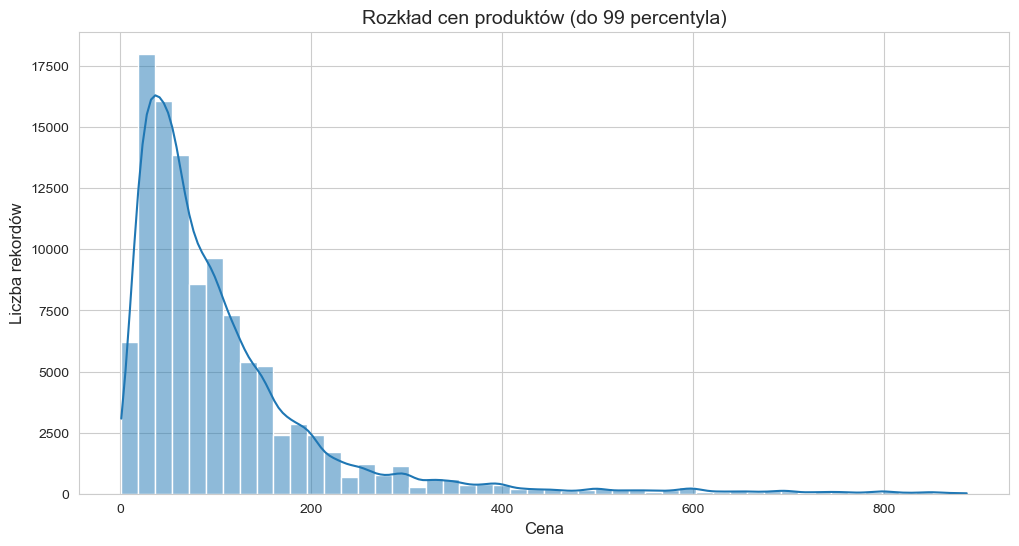

In [66]:
price_99 = delivered_df["price"].quantile(0.99)

filtered_price_df = delivered_df[delivered_df["price"] <= price_99]

plt.figure(figsize=(12, 6))
sns.histplot(filtered_price_df["price"], bins=50, kde=True)

plt.title("Rozkład cen produktów (do 99 percentyla)")
plt.xlabel("Cena")
plt.ylabel("Liczba rekordów")
plt.show()

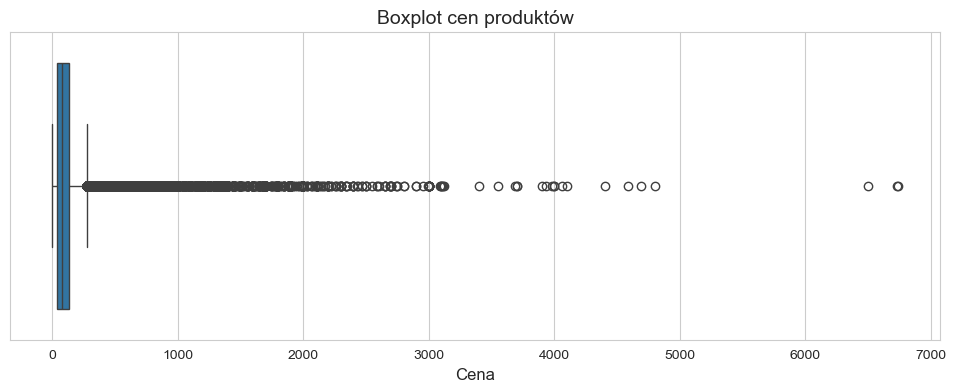

In [67]:
plt.figure(figsize=(12, 4))
sns.boxplot(x=delivered_df["price"])

plt.title("Boxplot cen produktów")
plt.xlabel("Cena")
plt.show()

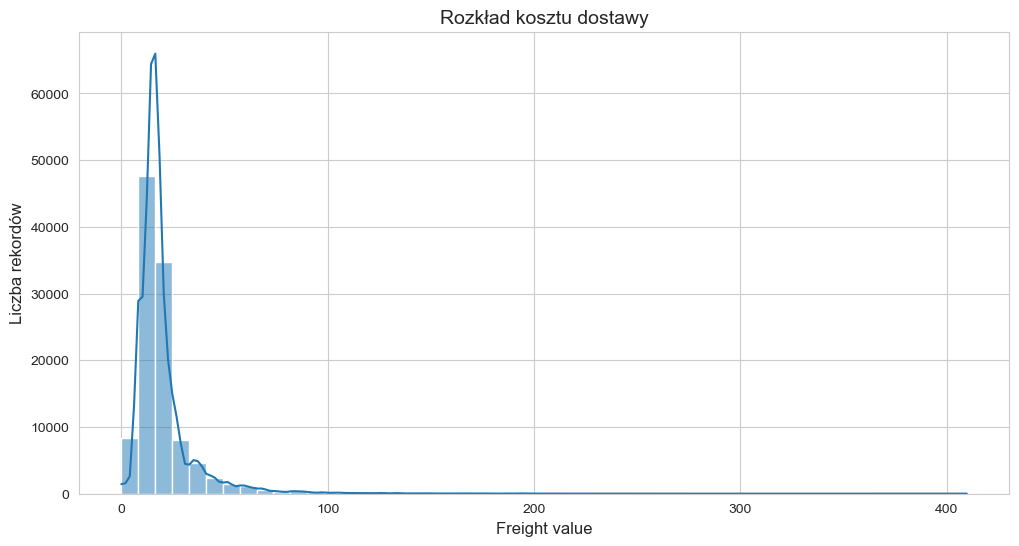

In [68]:
plt.figure(figsize=(12, 6))
sns.histplot(delivered_df["freight_value"], bins=50, kde=True)

plt.title("Rozkład kosztu dostawy")
plt.xlabel("Freight value")
plt.ylabel("Liczba rekordów")
plt.show()

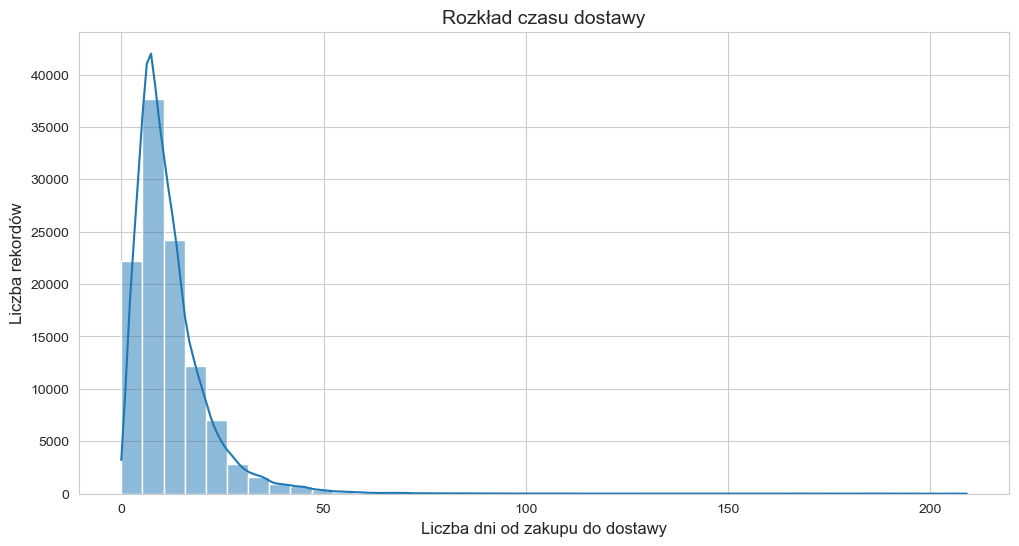

In [69]:
plt.figure(figsize=(12, 6))
sns.histplot(delivered_df["delivery_days"].dropna(), bins=40, kde=True)

plt.title("Rozkład czasu dostawy")
plt.xlabel("Liczba dni od zakupu do dostawy")
plt.ylabel("Liczba rekordów")
plt.show()

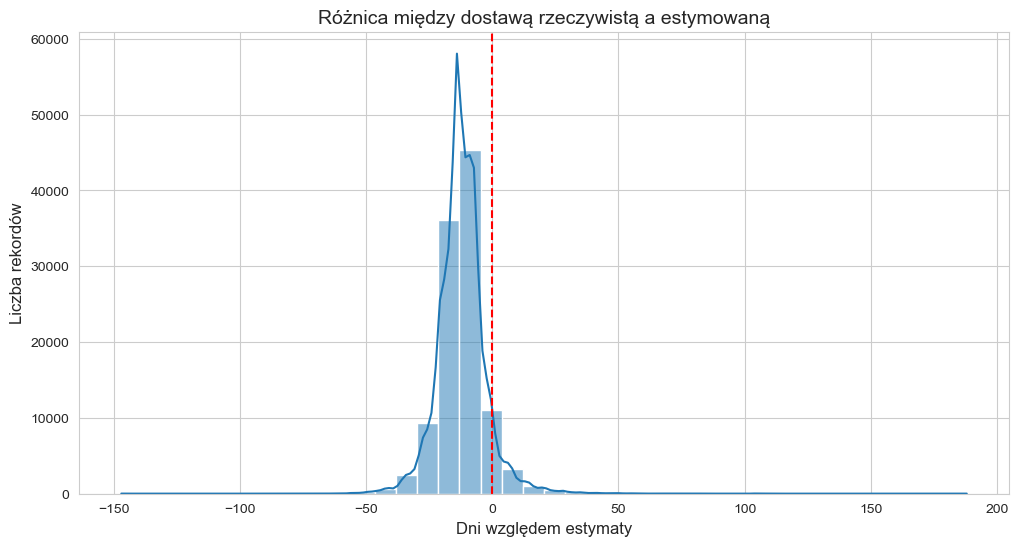

In [70]:
plt.figure(figsize=(12, 6))
sns.histplot(delivered_df["delivery_vs_estimate_days"].dropna(), bins=40, kde=True)

plt.title("Różnica między dostawą rzeczywistą a estymowaną")
plt.xlabel("Dni względem estymaty")
plt.ylabel("Liczba rekordów")
plt.axvline(0, color="red", linestyle="--")
plt.show()

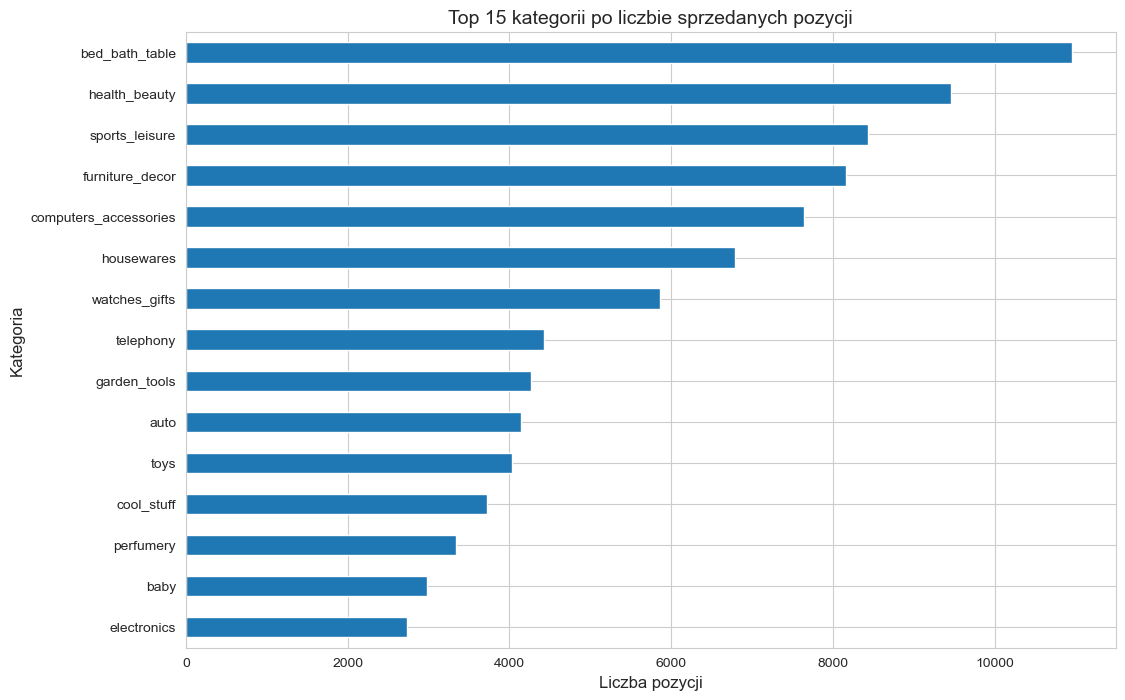

In [71]:
top_categories_count = (
    delivered_df["product_category_name_english"]
    .value_counts()
    .head(15)
    .sort_values()
)

plt.figure(figsize=(12, 8))
top_categories_count.plot(kind="barh")

plt.title("Top 15 kategorii po liczbie sprzedanych pozycji")
plt.xlabel("Liczba pozycji")
plt.ylabel("Kategoria")
plt.show()

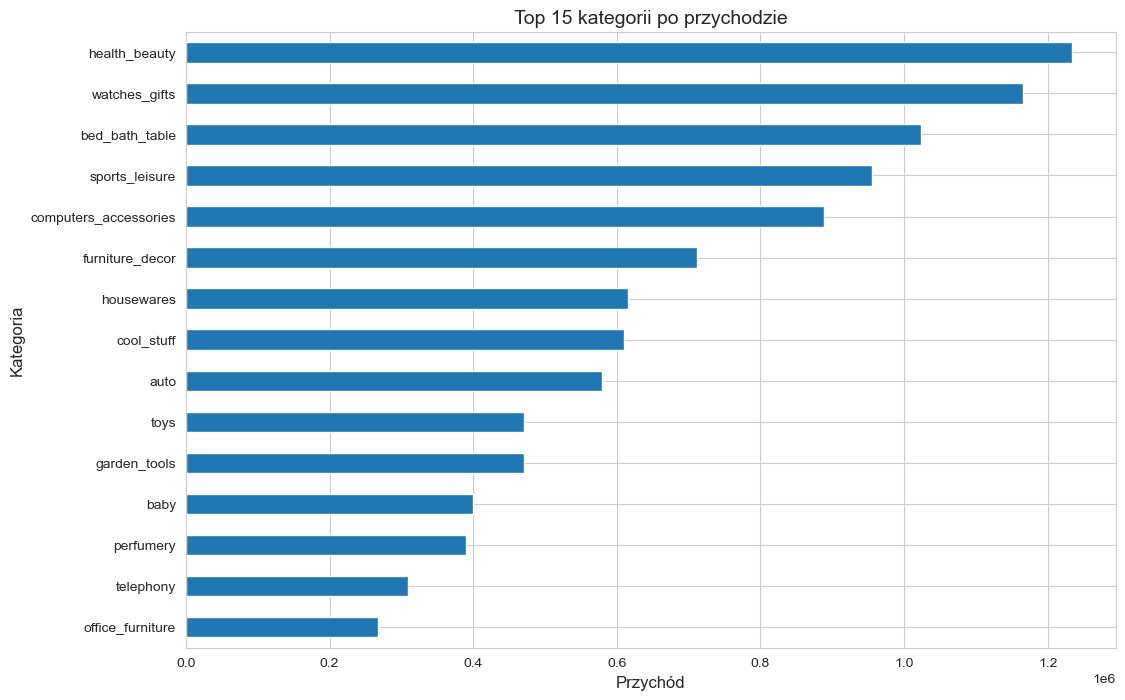

In [72]:
top_categories_revenue = (
    delivered_df.groupby("product_category_name_english")["price"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
    .sort_values()
)

plt.figure(figsize=(12, 8))
top_categories_revenue.plot(kind="barh")

plt.title("Top 15 kategorii po przychodzie")
plt.xlabel("Przychód")
plt.ylabel("Kategoria")
plt.show()

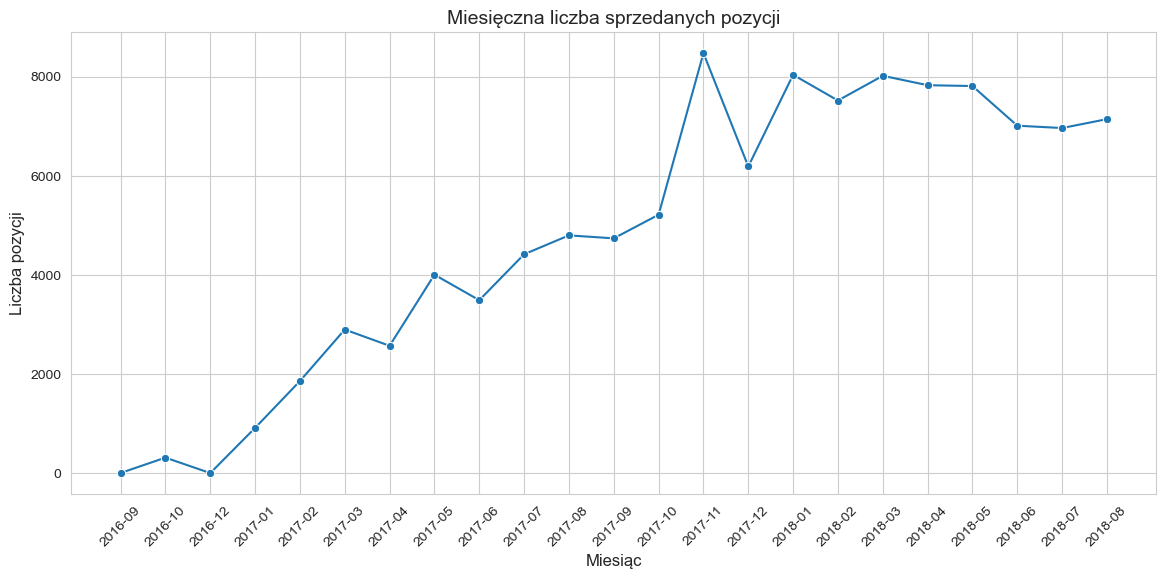

In [73]:
monthly_units = (
    delivered_df.groupby("purchase_month")
    .size()
    .reset_index(name="units_sold")
)

monthly_units["purchase_month"] = monthly_units["purchase_month"].astype(str)

plt.figure(figsize=(14, 6))
sns.lineplot(data=monthly_units, x="purchase_month", y="units_sold", marker="o")

plt.title("Miesięczna liczba sprzedanych pozycji")
plt.xlabel("Miesiąc")
plt.ylabel("Liczba pozycji")
plt.xticks(rotation=45)
plt.show()

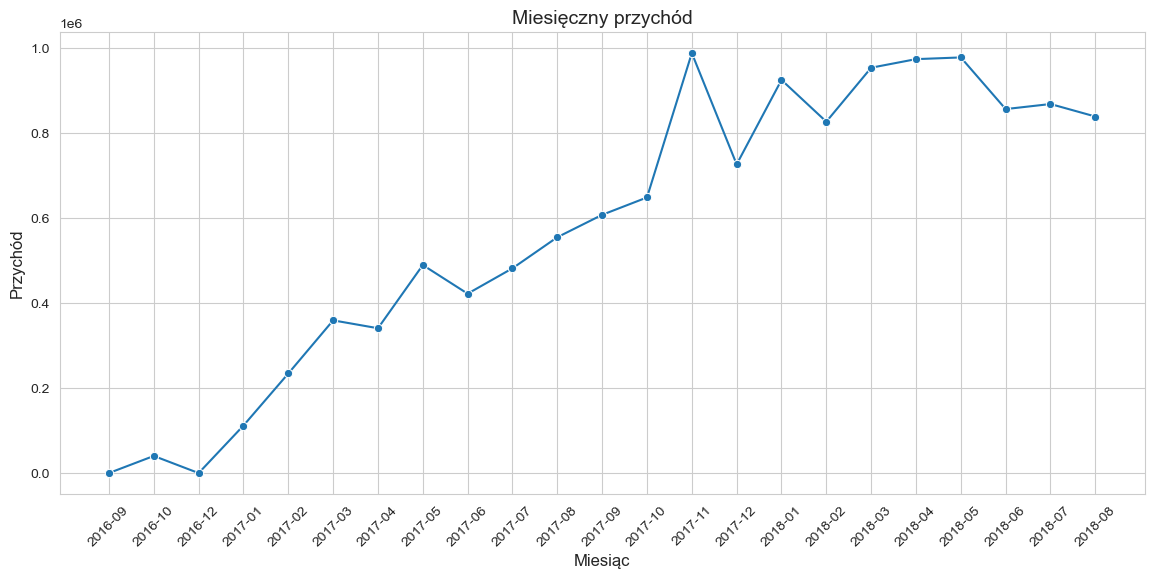

In [74]:
monthly_revenue = (
    delivered_df.groupby("purchase_month")["price"]
    .sum()
    .reset_index(name="revenue")
)

monthly_revenue["purchase_month"] = monthly_revenue["purchase_month"].astype(str)

plt.figure(figsize=(14, 6))
sns.lineplot(data=monthly_revenue, x="purchase_month", y="revenue", marker="o")

plt.title("Miesięczny przychód")
plt.xlabel("Miesiąc")
plt.ylabel("Przychód")
plt.xticks(rotation=45)
plt.show()

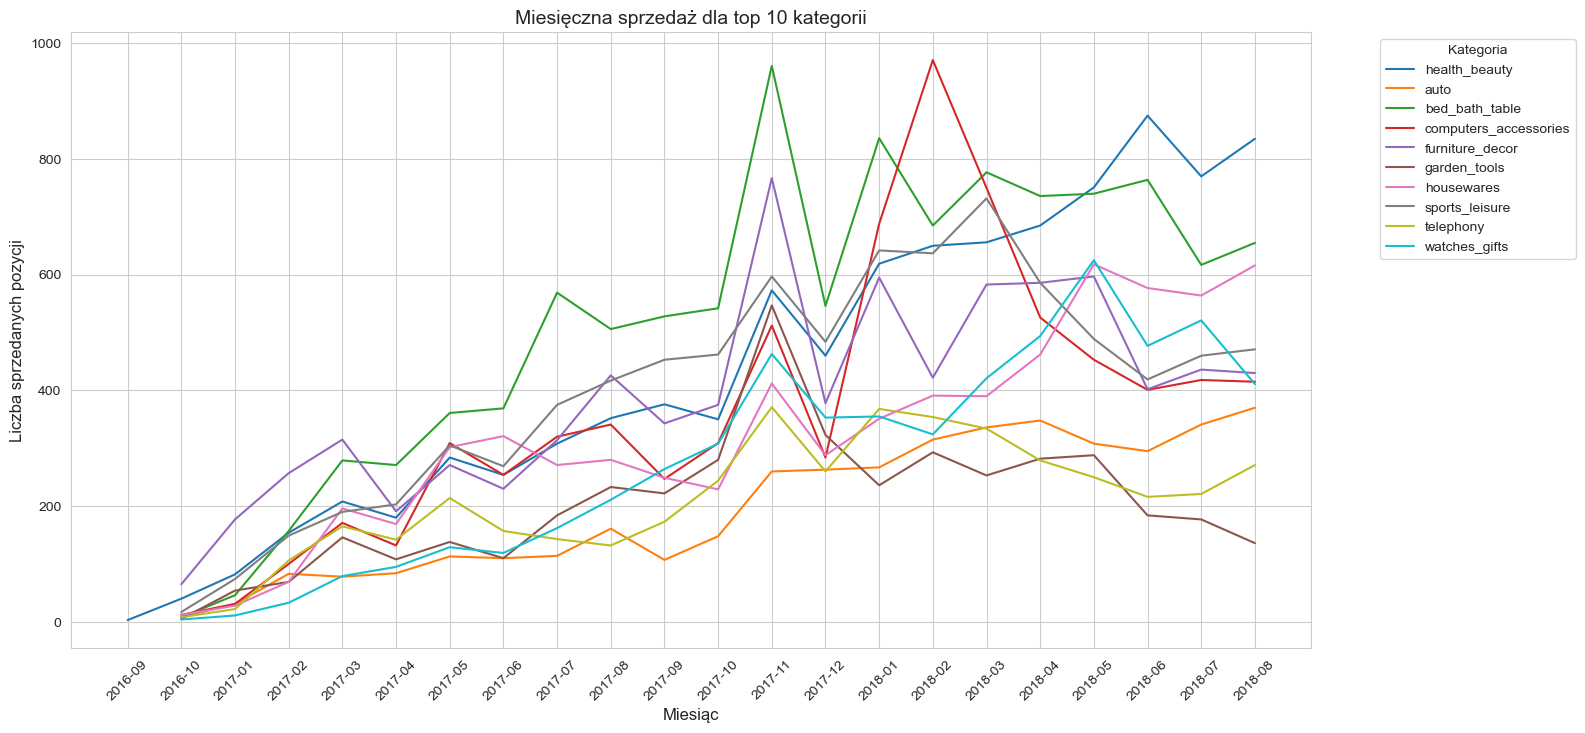

In [75]:
top_10_categories = (
    delivered_df["product_category_name_english"]
    .value_counts()
    .head(10)
    .index
)

monthly_top_categories = (
    delivered_df[delivered_df["product_category_name_english"].isin(top_10_categories)]
    .groupby(["purchase_month", "product_category_name_english"])
    .size()
    .reset_index(name="units_sold")
)

monthly_top_categories["purchase_month"] = monthly_top_categories["purchase_month"].astype(str)

plt.figure(figsize=(16, 8))
sns.lineplot(
    data=monthly_top_categories,
    x="purchase_month",
    y="units_sold",
    hue="product_category_name_english"
)

plt.title("Miesięczna sprzedaż dla top 10 kategorii")
plt.xlabel("Miesiąc")
plt.ylabel("Liczba sprzedanych pozycji")
plt.xticks(rotation=45)
plt.legend(title="Kategoria", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

wykres pokazuje sezonowość danej kategori i piki sprzedażowe 

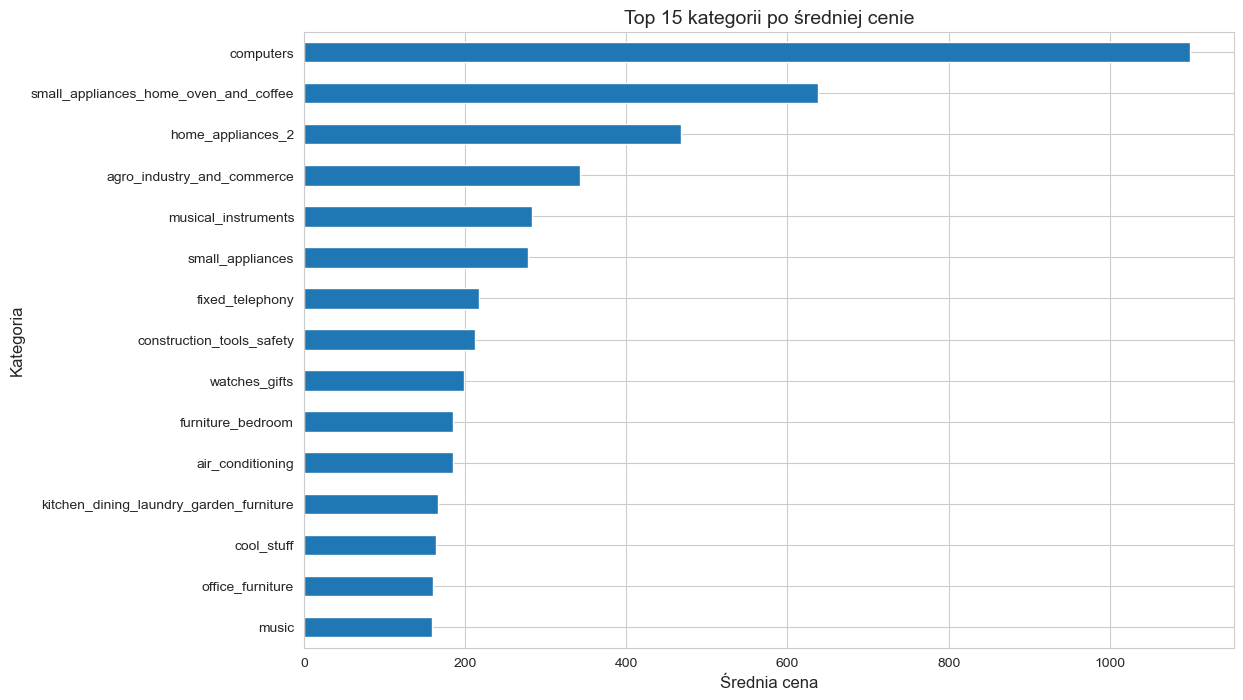

In [76]:
avg_price_top_categories = (
    delivered_df.groupby("product_category_name_english")["price"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
    .sort_values()
)

plt.figure(figsize=(12, 8))
avg_price_top_categories.plot(kind="barh")

plt.title("Top 15 kategorii po średniej cenie")
plt.xlabel("Średnia cena")
plt.ylabel("Kategoria")
plt.show()

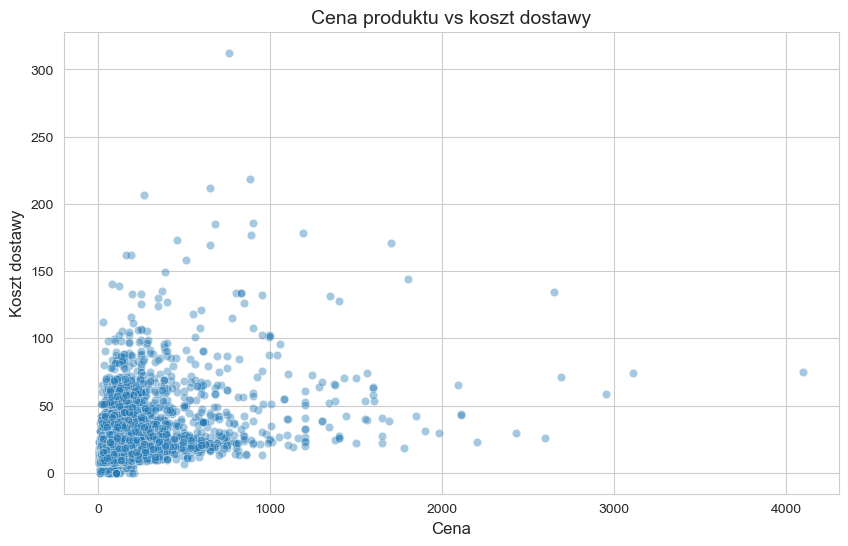

In [77]:
sample_df = delivered_df.sample(min(10000, len(delivered_df)), random_state=42)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=sample_df, x="price", y="freight_value", alpha=0.4)

plt.title("Cena produktu vs koszt dostawy")
plt.xlabel("Cena")
plt.ylabel("Koszt dostawy")
plt.show()

korelacja ceny produktu do kosztów dostaw, logistyka i transport maja wpływ na cene całkowitą i zamówienia 

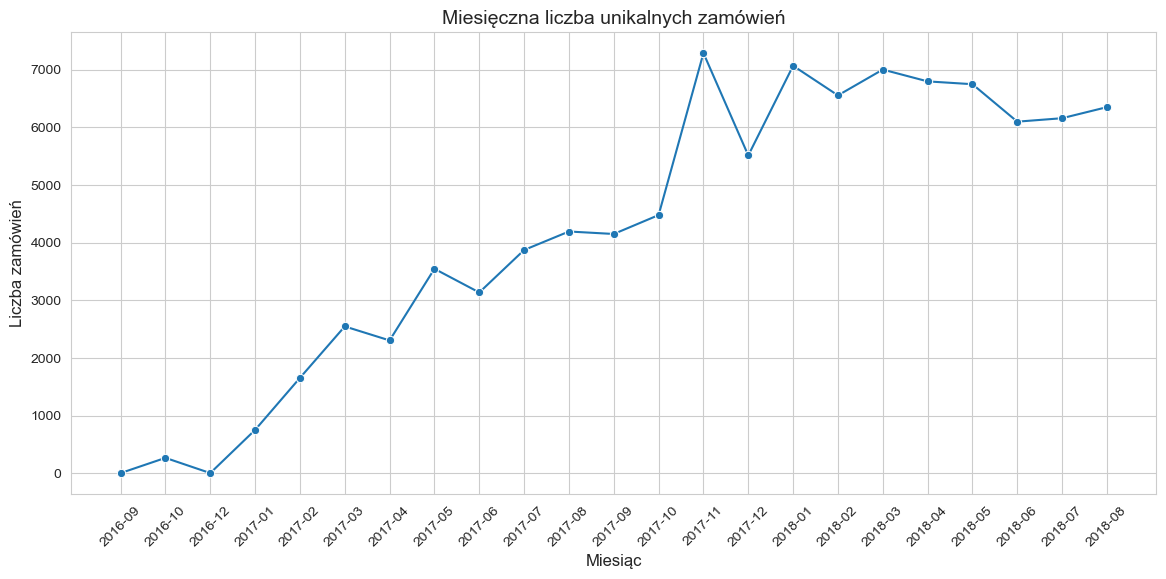

In [78]:
monthly_orders = (
    delivered_df.groupby("purchase_month")["order_id"]
    .nunique()
    .reset_index(name="unique_orders")
)

monthly_orders["purchase_month"] = monthly_orders["purchase_month"].astype(str)

plt.figure(figsize=(14, 6))
sns.lineplot(data=monthly_orders, x="purchase_month", y="unique_orders", marker="o")

plt.title("Miesięczna liczba unikalnych zamówień")
plt.xlabel("Miesiąc")
plt.ylabel("Liczba zamówień")
plt.xticks(rotation=45)
plt.show()

In [79]:
total_orders = delivered_df["order_id"].nunique()
total_products_sold = len(delivered_df)
total_revenue = delivered_df["price"].sum()
avg_price = delivered_df["price"].mean()
avg_freight = delivered_df["freight_value"].mean()
avg_delivery_days = delivered_df["delivery_days"].mean()

print("Unikalne zamówienia:", total_orders)
print("Liczba sprzedanych pozycji:", total_products_sold)
print("Łączny przychód:", round(total_revenue, 2))
print("Średnia cena:", round(avg_price, 2))
print("Średni koszt dostawy:", round(avg_freight, 2))
print("Średni czas dostawy:", round(avg_delivery_days, 2))

Unikalne zamówienia: 96478
Liczba sprzedanych pozycji: 110197
Łączny przychód: 13221498.11
Średnia cena: 119.98
Średni koszt dostawy: 19.95
Średni czas dostawy: 12.01


Sprzedaż ma piki sezonowe, rośnie w czasie 

Features Engineering 

przygotowanie bazowej tabeli tygodniowej

In [80]:
ts_df = delivered_df[
    [
        "order_purchase_timestamp",
        "product_category_name_english",
        "order_id",
        "product_id",
        "price",
        "freight_value"
    ]
].copy()

ts_df.head()

,order_purchase_timestamp,product_category_name_english,order_id,product_id,price,freight_value
0,2017-09-13 08:59:02,cool_stuff,00010242fe8c5a6d1ba2dd792cb16214,4244733e06e7ecb4970a6e2683c13e61,58.90,13.29
1,2017-04-26 10:53:06,pet_shop,00018f77f2f0320c557190d7a144bdd3,e5f2d52b802189ee658865ca93d83a8f,239.90,19.93
2,2018-01-14 14:33:31,furniture_decor,000229ec398224ef6ca0657da4fc703e,c777355d18b72b67abbeef9df44fd0fd,199.00,17.87
3,2018-08-08 10:00:35,perfumery,00024acbcdf0a6daa1e931b038114c75,7634da152a4610f1595efa32f14722fc,12.99,12.79
4,2017-02-04 13:57:51,garden_tools,00042b26cf59d7ce69dfabb4e55b4fd9,ac6c3623068f30de03045865e4e10089,199.90,18.14


In [81]:
ts_df = ts_df.dropna(subset=["product_category_name_english"]).copy()

print("Liczba rekordów po usunięciu braków kategorii:", len(ts_df))
print("Liczba unikalnych kategorii:", ts_df["product_category_name_english"].nunique())

Liczba rekordów po usunięciu braków kategorii: 108638
Liczba unikalnych kategorii: 71


In [82]:
ts_df["purchase_week_start"] = (
    ts_df["order_purchase_timestamp"]
    .dt.to_period("W")
    .apply(lambda r: r.start_time)
)

ts_df[["order_purchase_timestamp", "purchase_week_start"]].head()

,order_purchase_timestamp,purchase_week_start
0,2017-09-13 08:59:02,2017-09-11
1,2017-04-26 10:53:06,2017-04-24
2,2018-01-14 14:33:31,2018-01-08
3,2018-08-08 10:00:35,2018-08-06
4,2017-02-04 13:57:51,2017-01-30


In [83]:
weekly_df = (
    ts_df.groupby(["product_category_name_english", "purchase_week_start"])
    .agg(
        units_sold=("product_id", "count"),
        unique_orders=("order_id", "nunique"),
        revenue=("price", "sum"),
        avg_price=("price", "mean"),
        avg_freight=("freight_value", "mean")
    )
    .reset_index()
)

weekly_df.head()

,product_category_name_english,purchase_week_start,units_sold,unique_orders,revenue,avg_price,avg_freight
0,agro_industry_and_commerce,2017-01-23,2,1,43.98,21.990,8.720
1,agro_industry_and_commerce,2017-01-30,2,2,43.98,21.990,19.435
2,agro_industry_and_commerce,2017-02-06,2,2,114.89,57.445,19.375
3,agro_industry_and_commerce,2017-02-13,3,3,65.97,21.990,12.960
4,agro_industry_and_commerce,2017-02-20,1,1,21.99,21.990,14.110


In [84]:
print("Shape weekly_df:", weekly_df.shape)
print("Zakres czasu od:", weekly_df["purchase_week_start"].min())
print("Zakres czasu do:", weekly_df["purchase_week_start"].max())
print("Liczba kategorii:", weekly_df["product_category_name_english"].nunique())

weekly_df.sample(10, random_state=42)

Shape weekly_df: (4359, 7)
Zakres czasu od: 2016-09-12 00:00:00
Zakres czasu do: 2018-08-27 00:00:00
Liczba kategorii: 71


,product_category_name_english,purchase_week_start,units_sold,unique_orders,revenue,avg_price,avg_freight
1509,electronics,2016-10-03,1,1,107.99,107.990000,11.800000
2232,furniture_decor,2017-01-16,68,54,4709.22,69.253235,15.576324
643,books_imported,2018-01-15,2,2,147.00,73.500000,14.260000
2346,furniture_living_room,2017-08-28,3,3,439.88,146.626667,23.313333
3917,sports_leisure,2017-10-16,110,99,12102.07,110.018818,17.546091
2460,garden_tools,2017-10-02,80,56,8286.96,103.587000,23.801625
1515,electronics,2017-02-27,11,7,431.90,39.263636,16.361818
3554,perfumery,2017-06-26,28,25,4134.19,147.649643,14.888214
2684,home_appliances_2,2017-05-22,1,1,89.99,89.990000,15.380000
1621,fashio_female_clothing,2018-08-20,2,1,94.98,47.490000,8.490000


uzupełnienie brakujących tygodni

In [85]:
all_categories = weekly_df["product_category_name_english"].unique()
all_weeks = pd.date_range(
    start=weekly_df["purchase_week_start"].min(),
    end=weekly_df["purchase_week_start"].max(),
    freq="W-MON"
)

full_index = pd.MultiIndex.from_product(
    [all_categories, all_weeks],
    names=["product_category_name_english", "purchase_week_start"]
)

weekly_full = (
    weekly_df.set_index(["product_category_name_english", "purchase_week_start"])
    .reindex(full_index)
    .reset_index()
)

weekly_full.head()

,product_category_name_english,purchase_week_start,units_sold,unique_orders,revenue,avg_price,avg_freight
0,agro_industry_and_commerce,2016-09-12,NaN,NaN,NaN,NaN,NaN
1,agro_industry_and_commerce,2016-09-19,NaN,NaN,NaN,NaN,NaN
2,agro_industry_and_commerce,2016-09-26,NaN,NaN,NaN,NaN,NaN
3,agro_industry_and_commerce,2016-10-03,NaN,NaN,NaN,NaN,NaN
4,agro_industry_and_commerce,2016-10-10,NaN,NaN,NaN,NaN,NaN


In [86]:
weekly_full["units_sold"] = weekly_full["units_sold"].fillna(0)
weekly_full["unique_orders"] = weekly_full["unique_orders"].fillna(0)
weekly_full["revenue"] = weekly_full["revenue"].fillna(0)

weekly_full["avg_price"] = weekly_full["avg_price"].fillna(0)
weekly_full["avg_freight"] = weekly_full["avg_freight"].fillna(0)

weekly_full.head(10)

,product_category_name_english,purchase_week_start,units_sold,unique_orders,revenue,avg_price,avg_freight
0,agro_industry_and_commerce,2016-09-12,0.0,0.0,0.0,0.0,0.0
1,agro_industry_and_commerce,2016-09-19,0.0,0.0,0.0,0.0,0.0
2,agro_industry_and_commerce,2016-09-26,0.0,0.0,0.0,0.0,0.0
3,agro_industry_and_commerce,2016-10-03,0.0,0.0,0.0,0.0,0.0
4,agro_industry_and_commerce,2016-10-10,0.0,0.0,0.0,0.0,0.0
5,agro_industry_and_commerce,2016-10-17,0.0,0.0,0.0,0.0,0.0
6,agro_industry_and_commerce,2016-10-24,0.0,0.0,0.0,0.0,0.0
7,agro_industry_and_commerce,2016-10-31,0.0,0.0,0.0,0.0,0.0
8,agro_industry_and_commerce,2016-11-07,0.0,0.0,0.0,0.0,0.0
9,agro_industry_and_commerce,2016-11-14,0.0,0.0,0.0,0.0,0.0


In [87]:
weekly_full = weekly_full.sort_values(
    ["product_category_name_english", "purchase_week_start"]
).reset_index(drop=True)

weekly_full.head(10)

,product_category_name_english,purchase_week_start,units_sold,unique_orders,revenue,avg_price,avg_freight
0,agro_industry_and_commerce,2016-09-12,0.0,0.0,0.0,0.0,0.0
1,agro_industry_and_commerce,2016-09-19,0.0,0.0,0.0,0.0,0.0
2,agro_industry_and_commerce,2016-09-26,0.0,0.0,0.0,0.0,0.0
3,agro_industry_and_commerce,2016-10-03,0.0,0.0,0.0,0.0,0.0
4,agro_industry_and_commerce,2016-10-10,0.0,0.0,0.0,0.0,0.0
5,agro_industry_and_commerce,2016-10-17,0.0,0.0,0.0,0.0,0.0
6,agro_industry_and_commerce,2016-10-24,0.0,0.0,0.0,0.0,0.0
7,agro_industry_and_commerce,2016-10-31,0.0,0.0,0.0,0.0,0.0
8,agro_industry_and_commerce,2016-11-07,0.0,0.0,0.0,0.0,0.0
9,agro_industry_and_commerce,2016-11-14,0.0,0.0,0.0,0.0,0.0


cechy kalendarzowe

In [88]:
weekly_full["year"] = weekly_full["purchase_week_start"].dt.year
weekly_full["month"] = weekly_full["purchase_week_start"].dt.month
weekly_full["quarter"] = weekly_full["purchase_week_start"].dt.quarter
weekly_full["week_of_year"] = weekly_full["purchase_week_start"].dt.isocalendar().week.astype(int)

weekly_full.head()

,product_category_name_english,purchase_week_start,units_sold,unique_orders,revenue,avg_price,avg_freight,year,month,quarter,week_of_year
0,agro_industry_and_commerce,2016-09-12,0.0,0.0,0.0,0.0,0.0,2016,9,3,37
1,agro_industry_and_commerce,2016-09-19,0.0,0.0,0.0,0.0,0.0,2016,9,3,38
2,agro_industry_and_commerce,2016-09-26,0.0,0.0,0.0,0.0,0.0,2016,9,3,39
3,agro_industry_and_commerce,2016-10-03,0.0,0.0,0.0,0.0,0.0,2016,10,4,40
4,agro_industry_and_commerce,2016-10-10,0.0,0.0,0.0,0.0,0.0,2016,10,4,41


In [89]:
weekly_full["is_month_start"] = weekly_full["purchase_week_start"].dt.is_month_start.astype(int)
weekly_full["is_month_end"] = weekly_full["purchase_week_start"].dt.is_month_end.astype(int)
weekly_full["is_quarter_start"] = weekly_full["purchase_week_start"].dt.is_quarter_start.astype(int)
weekly_full["is_quarter_end"] = weekly_full["purchase_week_start"].dt.is_quarter_end.astype(int)

weekly_full.head()

,product_category_name_english,purchase_week_start,units_sold,unique_orders,revenue,avg_price,avg_freight,year,month,quarter,week_of_year,is_month_start,is_month_end,is_quarter_start,is_quarter_end
0,agro_industry_and_commerce,2016-09-12,0.0,0.0,0.0,0.0,0.0,2016,9,3,37,0,0,0,0
1,agro_industry_and_commerce,2016-09-19,0.0,0.0,0.0,0.0,0.0,2016,9,3,38,0,0,0,0
2,agro_industry_and_commerce,2016-09-26,0.0,0.0,0.0,0.0,0.0,2016,9,3,39,0,0,0,0
3,agro_industry_and_commerce,2016-10-03,0.0,0.0,0.0,0.0,0.0,2016,10,4,40,0,0,0,0
4,agro_industry_and_commerce,2016-10-10,0.0,0.0,0.0,0.0,0.0,2016,10,4,41,0,0,0,0


lagi - opóźnione wartości zmiennej z przeszłości.

 najważniejsze lagi targetu

In [90]:
weekly_full["lag_1"] = (
    weekly_full.groupby("product_category_name_english")["units_sold"].shift(1)
)

weekly_full["lag_2"] = (
    weekly_full.groupby("product_category_name_english")["units_sold"].shift(2)
)

weekly_full["lag_4"] = (
    weekly_full.groupby("product_category_name_english")["units_sold"].shift(4)
)

weekly_full["lag_8"] = (
    weekly_full.groupby("product_category_name_english")["units_sold"].shift(8)
)

weekly_full.head(15)

,product_category_name_english,purchase_week_start,units_sold,unique_orders,revenue,avg_price,avg_freight,year,month,quarter,week_of_year,is_month_start,is_month_end,is_quarter_start,is_quarter_end,lag_1,lag_2,lag_4,lag_8
0,agro_industry_and_commerce,2016-09-12,0.0,0.0,0.0,0.0,0.0,2016,9,3,37,0,0,0,0,NaN,NaN,NaN,NaN
1,agro_industry_and_commerce,2016-09-19,0.0,0.0,0.0,0.0,0.0,2016,9,3,38,0,0,0,0,0.0,NaN,NaN,NaN
2,agro_industry_and_commerce,2016-09-26,0.0,0.0,0.0,0.0,0.0,2016,9,3,39,0,0,0,0,0.0,0.0,NaN,NaN
3,agro_industry_and_commerce,2016-10-03,0.0,0.0,0.0,0.0,0.0,2016,10,4,40,0,0,0,0,0.0,0.0,NaN,NaN
4,agro_industry_and_commerce,2016-10-10,0.0,0.0,0.0,0.0,0.0,2016,10,4,41,0,0,0,0,0.0,0.0,0.0,NaN
5,agro_industry_and_commerce,2016-10-17,0.0,0.0,0.0,0.0,0.0,2016,10,4,42,0,0,0,0,0.0,0.0,0.0,NaN
6,agro_industry_and_commerce,2016-10-24,0.0,0.0,0.0,0.0,0.0,2016,10,4,43,0,0,0,0,0.0,0.0,0.0,NaN
7,agro_industry_and_commerce,2016-10-31,0.0,0.0,0.0,0.0,0.0,2016,10,4,44,0,1,0,0,0.0,0.0,0.0,NaN
8,agro_industry_and_commerce,2016-11-07,0.0,0.0,0.0,0.0,0.0,2016,11,4,45,0,0,0,0,0.0,0.0,0.0,0.0
9,agro_industry_and_commerce,2016-11-14,0.0,0.0,0.0,0.0,0.0,2016,11,4,46,0,0,0,0,0.0,0.0,0.0,0.0


lagi dodatkowych sygnałów

In [91]:
weekly_full["revenue_lag_1"] = (
    weekly_full.groupby("product_category_name_english")["revenue"].shift(1)
)

weekly_full["orders_lag_1"] = (
    weekly_full.groupby("product_category_name_english")["unique_orders"].shift(1)
)

weekly_full["avg_price_lag_1"] = (
    weekly_full.groupby("product_category_name_english")["avg_price"].shift(1)
)

weekly_full.head(15)

,product_category_name_english,purchase_week_start,units_sold,unique_orders,revenue,avg_price,avg_freight,year,month,quarter,...,is_month_end,is_quarter_start,is_quarter_end,lag_1,lag_2,lag_4,lag_8,revenue_lag_1,orders_lag_1,avg_price_lag_1
0,agro_industry_and_commerce,2016-09-12,0.0,0.0,0.0,0.0,0.0,2016,9,3,...,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,agro_industry_and_commerce,2016-09-19,0.0,0.0,0.0,0.0,0.0,2016,9,3,...,0,0,0,0.0,NaN,NaN,NaN,0.0,0.0,0.0
2,agro_industry_and_commerce,2016-09-26,0.0,0.0,0.0,0.0,0.0,2016,9,3,...,0,0,0,0.0,0.0,NaN,NaN,0.0,0.0,0.0
3,agro_industry_and_commerce,2016-10-03,0.0,0.0,0.0,0.0,0.0,2016,10,4,...,0,0,0,0.0,0.0,NaN,NaN,0.0,0.0,0.0
4,agro_industry_and_commerce,2016-10-10,0.0,0.0,0.0,0.0,0.0,2016,10,4,...,0,0,0,0.0,0.0,0.0,NaN,0.0,0.0,0.0
5,agro_industry_and_commerce,2016-10-17,0.0,0.0,0.0,0.0,0.0,2016,10,4,...,0,0,0,0.0,0.0,0.0,NaN,0.0,0.0,0.0
6,agro_industry_and_commerce,2016-10-24,0.0,0.0,0.0,0.0,0.0,2016,10,4,...,0,0,0,0.0,0.0,0.0,NaN,0.0,0.0,0.0
7,agro_industry_and_commerce,2016-10-31,0.0,0.0,0.0,0.0,0.0,2016,10,4,...,1,0,0,0.0,0.0,0.0,NaN,0.0,0.0,0.0
8,agro_industry_and_commerce,2016-11-07,0.0,0.0,0.0,0.0,0.0,2016,11,4,...,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,agro_industry_and_commerce,2016-11-14,0.0,0.0,0.0,0.0,0.0,2016,11,4,...,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


rolling features

 rolling mean i rolling std dla targetu

In [92]:
weekly_full["rolling_mean_4"] = (
    weekly_full.groupby("product_category_name_english")["units_sold"]
    .transform(lambda x: x.shift(1).rolling(window=4).mean())
)

weekly_full["rolling_std_4"] = (
    weekly_full.groupby("product_category_name_english")["units_sold"]
    .transform(lambda x: x.shift(1).rolling(window=4).std())
)

weekly_full["rolling_mean_8"] = (
    weekly_full.groupby("product_category_name_english")["units_sold"]
    .transform(lambda x: x.shift(1).rolling(window=8).mean())
)

weekly_full.head(15)

,product_category_name_english,purchase_week_start,units_sold,unique_orders,revenue,avg_price,avg_freight,year,month,quarter,...,lag_1,lag_2,lag_4,lag_8,revenue_lag_1,orders_lag_1,avg_price_lag_1,rolling_mean_4,rolling_std_4,rolling_mean_8
0,agro_industry_and_commerce,2016-09-12,0.0,0.0,0.0,0.0,0.0,2016,9,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,agro_industry_and_commerce,2016-09-19,0.0,0.0,0.0,0.0,0.0,2016,9,3,...,0.0,NaN,NaN,NaN,0.0,0.0,0.0,NaN,NaN,NaN
2,agro_industry_and_commerce,2016-09-26,0.0,0.0,0.0,0.0,0.0,2016,9,3,...,0.0,0.0,NaN,NaN,0.0,0.0,0.0,NaN,NaN,NaN
3,agro_industry_and_commerce,2016-10-03,0.0,0.0,0.0,0.0,0.0,2016,10,4,...,0.0,0.0,NaN,NaN,0.0,0.0,0.0,NaN,NaN,NaN
4,agro_industry_and_commerce,2016-10-10,0.0,0.0,0.0,0.0,0.0,2016,10,4,...,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,NaN
5,agro_industry_and_commerce,2016-10-17,0.0,0.0,0.0,0.0,0.0,2016,10,4,...,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,NaN
6,agro_industry_and_commerce,2016-10-24,0.0,0.0,0.0,0.0,0.0,2016,10,4,...,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,NaN
7,agro_industry_and_commerce,2016-10-31,0.0,0.0,0.0,0.0,0.0,2016,10,4,...,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,NaN
8,agro_industry_and_commerce,2016-11-07,0.0,0.0,0.0,0.0,0.0,2016,11,4,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,agro_industry_and_commerce,2016-11-14,0.0,0.0,0.0,0.0,0.0,2016,11,4,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [93]:
weekly_full["revenue_roll_mean_4"] = (
    weekly_full.groupby("product_category_name_english")["revenue"]
    .transform(lambda x: x.shift(1).rolling(window=4).mean())
)

weekly_full["revenue_roll_std_4"] = (
    weekly_full.groupby("product_category_name_english")["revenue"]
    .transform(lambda x: x.shift(1).rolling(window=4).std())
)

weekly_full.head(15)

,product_category_name_english,purchase_week_start,units_sold,unique_orders,revenue,avg_price,avg_freight,year,month,quarter,...,lag_4,lag_8,revenue_lag_1,orders_lag_1,avg_price_lag_1,rolling_mean_4,rolling_std_4,rolling_mean_8,revenue_roll_mean_4,revenue_roll_std_4
0,agro_industry_and_commerce,2016-09-12,0.0,0.0,0.0,0.0,0.0,2016,9,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,agro_industry_and_commerce,2016-09-19,0.0,0.0,0.0,0.0,0.0,2016,9,3,...,NaN,NaN,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
2,agro_industry_and_commerce,2016-09-26,0.0,0.0,0.0,0.0,0.0,2016,9,3,...,NaN,NaN,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
3,agro_industry_and_commerce,2016-10-03,0.0,0.0,0.0,0.0,0.0,2016,10,4,...,NaN,NaN,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
4,agro_industry_and_commerce,2016-10-10,0.0,0.0,0.0,0.0,0.0,2016,10,4,...,0.0,NaN,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0
5,agro_industry_and_commerce,2016-10-17,0.0,0.0,0.0,0.0,0.0,2016,10,4,...,0.0,NaN,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0
6,agro_industry_and_commerce,2016-10-24,0.0,0.0,0.0,0.0,0.0,2016,10,4,...,0.0,NaN,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0
7,agro_industry_and_commerce,2016-10-31,0.0,0.0,0.0,0.0,0.0,2016,10,4,...,0.0,NaN,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0
8,agro_industry_and_commerce,2016-11-07,0.0,0.0,0.0,0.0,0.0,2016,11,4,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,agro_industry_and_commerce,2016-11-14,0.0,0.0,0.0,0.0,0.0,2016,11,4,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


trend i momentum
Momentum mówi, czy ostatni tydzień był:

powyżej typowego poziomu,

poniżej typowego poziomu.

In [94]:
weekly_full["momentum_1_4"] = weekly_full["lag_1"] - weekly_full["rolling_mean_4"]
weekly_full["momentum_1_8"] = weekly_full["lag_1"] - weekly_full["rolling_mean_8"]

weekly_full.head(15)

,product_category_name_english,purchase_week_start,units_sold,unique_orders,revenue,avg_price,avg_freight,year,month,quarter,...,revenue_lag_1,orders_lag_1,avg_price_lag_1,rolling_mean_4,rolling_std_4,rolling_mean_8,revenue_roll_mean_4,revenue_roll_std_4,momentum_1_4,momentum_1_8
0,agro_industry_and_commerce,2016-09-12,0.0,0.0,0.0,0.0,0.0,2016,9,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,agro_industry_and_commerce,2016-09-19,0.0,0.0,0.0,0.0,0.0,2016,9,3,...,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,agro_industry_and_commerce,2016-09-26,0.0,0.0,0.0,0.0,0.0,2016,9,3,...,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,agro_industry_and_commerce,2016-10-03,0.0,0.0,0.0,0.0,0.0,2016,10,4,...,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,agro_industry_and_commerce,2016-10-10,0.0,0.0,0.0,0.0,0.0,2016,10,4,...,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,NaN
5,agro_industry_and_commerce,2016-10-17,0.0,0.0,0.0,0.0,0.0,2016,10,4,...,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,NaN
6,agro_industry_and_commerce,2016-10-24,0.0,0.0,0.0,0.0,0.0,2016,10,4,...,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,NaN
7,agro_industry_and_commerce,2016-10-31,0.0,0.0,0.0,0.0,0.0,2016,10,4,...,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,NaN
8,agro_industry_and_commerce,2016-11-07,0.0,0.0,0.0,0.0,0.0,2016,11,4,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,agro_industry_and_commerce,2016-11-14,0.0,0.0,0.0,0.0,0.0,2016,11,4,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [95]:
weekly_full["units_pct_change_1"] = (
    weekly_full.groupby("product_category_name_english")["units_sold"]
    .transform(lambda x: x.shift(1).pct_change())
)

weekly_full["revenue_pct_change_1"] = (
    weekly_full.groupby("product_category_name_english")["revenue"]
    .transform(lambda x: x.shift(1).pct_change())
)

weekly_full.head(15)

,product_category_name_english,purchase_week_start,units_sold,unique_orders,revenue,avg_price,avg_freight,year,month,quarter,...,avg_price_lag_1,rolling_mean_4,rolling_std_4,rolling_mean_8,revenue_roll_mean_4,revenue_roll_std_4,momentum_1_4,momentum_1_8,units_pct_change_1,revenue_pct_change_1
0,agro_industry_and_commerce,2016-09-12,0.0,0.0,0.0,0.0,0.0,2016,9,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,agro_industry_and_commerce,2016-09-19,0.0,0.0,0.0,0.0,0.0,2016,9,3,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,agro_industry_and_commerce,2016-09-26,0.0,0.0,0.0,0.0,0.0,2016,9,3,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,agro_industry_and_commerce,2016-10-03,0.0,0.0,0.0,0.0,0.0,2016,10,4,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,agro_industry_and_commerce,2016-10-10,0.0,0.0,0.0,0.0,0.0,2016,10,4,...,0.0,0.0,0.0,NaN,0.0,0.0,0.0,NaN,NaN,NaN
5,agro_industry_and_commerce,2016-10-17,0.0,0.0,0.0,0.0,0.0,2016,10,4,...,0.0,0.0,0.0,NaN,0.0,0.0,0.0,NaN,NaN,NaN
6,agro_industry_and_commerce,2016-10-24,0.0,0.0,0.0,0.0,0.0,2016,10,4,...,0.0,0.0,0.0,NaN,0.0,0.0,0.0,NaN,NaN,NaN
7,agro_industry_and_commerce,2016-10-31,0.0,0.0,0.0,0.0,0.0,2016,10,4,...,0.0,0.0,0.0,NaN,0.0,0.0,0.0,NaN,NaN,NaN
8,agro_industry_and_commerce,2016-11-07,0.0,0.0,0.0,0.0,0.0,2016,11,4,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
9,agro_industry_and_commerce,2016-11-14,0.0,0.0,0.0,0.0,0.0,2016,11,4,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN


In [96]:
# dodane z pliku Kacpra 

# rolling_mean12 i rolling_std12
weekly_full['rolling_mean12'] = (
    weekly_full
    .groupby('product_category_name_english')['units_sold']
    .transform(lambda x: x.shift(1).rolling(12).mean())
)
weekly_full['rolling_std12'] = (
    weekly_full
    .groupby('product_category_name_english')['units_sold']
    .transform(lambda x: x.shift(1).rolling(12).std())
)

weekly_full[['purchase_week_start','rolling_mean12','rolling_std12']].head(15)

,purchase_week_start,rolling_mean12,rolling_std12
0,2016-09-12,NaN,NaN
1,2016-09-19,NaN,NaN
2,2016-09-26,NaN,NaN
3,2016-10-03,NaN,NaN
4,2016-10-10,NaN,NaN
5,2016-10-17,NaN,NaN
6,2016-10-24,NaN,NaN
7,2016-10-31,NaN,NaN
8,2016-11-07,NaN,NaN
9,2016-11-14,NaN,NaN


In [97]:
# Święta brazylijskie - wpływają na sprzedaż
holidays_brazil = [
    '2017-01-01', '2017-04-14', '2017-04-21', '2017-05-01',
    '2017-06-15', '2017-09-07', '2017-10-12', '2017-11-02',
    '2017-11-15', '2017-12-25',
    '2018-01-01', '2018-03-30', '2018-04-21', '2018-05-01',
    '2018-05-31', '2018-09-07', '2018-10-12', '2018-11-02',
    '2018-11-15', '2018-12-25'
]

holidays_brazil = pd.to_datetime(holidays_brazil)

weekly_full['is_holiday_week'] = weekly_full['purchase_week_start'].apply(
    lambda x: 1 if any(
        (h >= x) & (h < x + pd.Timedelta(days=7))
        for h in holidays_brazil
    ) else 0
)

print("Tygodnie ze świętami:", weekly_full['is_holiday_week'].sum())
weekly_full[['purchase_week_start', 'is_holiday_week']].drop_duplicates().query('is_holiday_week == 1')

Tygodnie ze świętami: 1065


,purchase_week_start,is_holiday_week
15,2016-12-26,1
30,2017-04-10,1
31,2017-04-17,1
33,2017-05-01,1
39,2017-06-12,1
51,2017-09-04,1
56,2017-10-09,1
59,2017-10-30,1
61,2017-11-13,1
67,2017-12-25,1


In [98]:
# Średnia sprzedaż per kategoria - target encoding
category_mean = (
    weekly_full
    .groupby('product_category_name_english')['units_sold']
    .mean()
)

weekly_full['category_enc'] = (
    weekly_full['product_category_name_english']
    .map(category_mean)
)

print("Przykładowe wartości target encoding:")
print(category_mean.sort_values(ascending=False).head(10))

Przykładowe wartości target encoding:
product_category_name_english
bed_bath_table           106.339806
health_beauty             91.893204
sports_leisure            81.854369
furniture_decor           79.223301
computers_accessories     74.213592
housewares                65.970874
watches_gifts             56.883495
telephony                 43.009709
garden_tools              41.436893
auto                      40.194175
Name: units_sold, dtype: float64


trendy 

In [99]:
from scipy.stats import linregress

def calc_slope(x):
    if x.isna().sum() > len(x) // 2:
        return np.nan
    idx = np.arange(len(x))
    mask = ~np.isnan(x.values)
    if mask.sum() < 2:
        return np.nan
    slope, _, _, _, _ = linregress(idx[mask], x.values[mask])
    return slope

weekly_full['trend_slope_4w'] = (
    weekly_full
    .groupby('product_category_name_english')['units_sold']
    .transform(lambda x: x.shift(1).rolling(4).apply(calc_slope, raw=False))
)

weekly_full['trend_slope_8w'] = (
    weekly_full
    .groupby('product_category_name_english')['units_sold']
    .transform(lambda x: x.shift(1).rolling(8).apply(calc_slope, raw=False))
)

print("Gotowe!")
weekly_full[['purchase_week_start', 'product_category_name_english',
             'units_sold', 'trend_slope_4w', 'trend_slope_8w']].dropna().head(10)

Gotowe!


,purchase_week_start,product_category_name_english,units_sold,trend_slope_4w,trend_slope_8w
8,2016-11-07,agro_industry_and_commerce,0.0,0.0,0.0
9,2016-11-14,agro_industry_and_commerce,0.0,0.0,0.0
10,2016-11-21,agro_industry_and_commerce,0.0,0.0,0.0
11,2016-11-28,agro_industry_and_commerce,0.0,0.0,0.0
12,2016-12-05,agro_industry_and_commerce,0.0,0.0,0.0
13,2016-12-12,agro_industry_and_commerce,0.0,0.0,0.0
14,2016-12-19,agro_industry_and_commerce,0.0,0.0,0.0
15,2016-12-26,agro_industry_and_commerce,0.0,0.0,0.0
16,2017-01-02,agro_industry_and_commerce,0.0,0.0,0.0
17,2017-01-09,agro_industry_and_commerce,0.0,0.0,0.0


In [100]:
def classify_trend(slope, threshold=0.5):
    if pd.isna(slope):
        return np.nan
    elif slope > threshold:
        return 1    # UP
    elif slope < -threshold:
        return -1   # DOWN
    else:
        return 0    # STABLE

weekly_full['trend_direction'] = weekly_full['trend_slope_4w'].apply(classify_trend)

print("Rozkład trend_direction:")
print(weekly_full['trend_direction'].value_counts())

Rozkład trend_direction:
trend_direction
 0.0    3800
 1.0    1801
-1.0    1428
Name: count, dtype: int64


In [101]:
# Minimalny poziom magazynowy = max z ostatnich 4 tygodni + 20% bufor
weekly_full['min_stock_level'] = (
    weekly_full
    .groupby('product_category_name_english')['units_sold']
    .transform(lambda x: x.shift(1).rolling(4).max() * 1.2)
)

# Sygnał: 1 = sprzedaż w normie, 0 = sprzedaż przekracza poziom magazynowy
weekly_full['stock_safe_signal'] = (
    (weekly_full['units_sold'] <= weekly_full['min_stock_level'])
    .astype(int)
)

print("Rozkład stock_safe_signal:")
print(weekly_full['stock_safe_signal'].value_counts())
print("\nPrzykład:")
weekly_full[['purchase_week_start', 'product_category_name_english',
             'units_sold', 'min_stock_level', 'stock_safe_signal']].dropna().head(10)

Rozkład stock_safe_signal:
stock_safe_signal
1    6240
0    1073
Name: count, dtype: int64

Przykład:


,purchase_week_start,product_category_name_english,units_sold,min_stock_level,stock_safe_signal
4,2016-10-10,agro_industry_and_commerce,0.0,0.0,1
5,2016-10-17,agro_industry_and_commerce,0.0,0.0,1
6,2016-10-24,agro_industry_and_commerce,0.0,0.0,1
7,2016-10-31,agro_industry_and_commerce,0.0,0.0,1
8,2016-11-07,agro_industry_and_commerce,0.0,0.0,1
9,2016-11-14,agro_industry_and_commerce,0.0,0.0,1
10,2016-11-21,agro_industry_and_commerce,0.0,0.0,1
11,2016-11-28,agro_industry_and_commerce,0.0,0.0,1
12,2016-12-05,agro_industry_and_commerce,0.0,0.0,1
13,2016-12-12,agro_industry_and_commerce,0.0,0.0,1


czyszczenie feature’ów

 kontrola braków po feature engineeringu

In [102]:
weekly_full.isnull().sum().sort_values(ascending=False).head(20)

revenue_pct_change_1    2507
units_pct_change_1      2507
rolling_std12            852
rolling_mean12           852
momentum_1_8             568
trend_slope_8w           568
lag_8                    568
rolling_mean_8           568
momentum_1_4             284
rolling_mean_4           284
revenue_roll_mean_4      284
lag_4                    284
revenue_roll_std_4       284
rolling_std_4            284
trend_slope_4w           284
trend_direction          284
min_stock_level          284
lag_2                    142
lag_1                     71
revenue_lag_1             71
dtype: int64

 zamiana inf na NaN

In [103]:
weekly_full = weekly_full.replace([np.inf, -np.inf], np.nan)

 usunięcie rekordów bez minimalnej historii

In [104]:
feature_df = weekly_full.dropna(
    subset=[
        "lag_1",
        "lag_2",
        "lag_4",
        "rolling_mean_4",
        "rolling_mean_8"
    ]
).copy()

print("weekly_full shape:", weekly_full.shape)
print("feature_df shape:", feature_df.shape)

weekly_full shape: (7313, 40)
feature_df shape: (6745, 40)


 finalna tabela do modelu

In [105]:

model_df = feature_df.copy()

print("model_df shape:", model_df.shape)
model_df.head()

model_df shape: (6745, 40)


,product_category_name_english,purchase_week_start,units_sold,unique_orders,revenue,avg_price,avg_freight,year,month,quarter,...,revenue_pct_change_1,rolling_mean12,rolling_std12,is_holiday_week,category_enc,trend_slope_4w,trend_slope_8w,trend_direction,min_stock_level,stock_safe_signal
8,agro_industry_and_commerce,2016-11-07,0.0,0.0,0.0,0.0,0.0,2016,11,4,...,NaN,NaN,NaN,0,2.0,0.0,0.0,0.0,0.0,1
9,agro_industry_and_commerce,2016-11-14,0.0,0.0,0.0,0.0,0.0,2016,11,4,...,NaN,NaN,NaN,0,2.0,0.0,0.0,0.0,0.0,1
10,agro_industry_and_commerce,2016-11-21,0.0,0.0,0.0,0.0,0.0,2016,11,4,...,NaN,NaN,NaN,0,2.0,0.0,0.0,0.0,0.0,1
11,agro_industry_and_commerce,2016-11-28,0.0,0.0,0.0,0.0,0.0,2016,11,4,...,NaN,NaN,NaN,0,2.0,0.0,0.0,0.0,0.0,1
12,agro_industry_and_commerce,2016-12-05,0.0,0.0,0.0,0.0,0.0,2016,12,4,...,NaN,0.0,0.0,0,2.0,0.0,0.0,0.0,0.0,1


końcowa kontrola jakości i zapis pliku 

In [106]:
print("Shape model_df:", model_df.shape)
print("Nulls w model_df:")
print(model_df.isnull().sum().sort_values(ascending=False).head(20))

print("\nLiczba kategorii:", model_df["product_category_name_english"].nunique())
print("Pierwsza data:", model_df["purchase_week_start"].min())
print("Ostatnia data:", model_df["purchase_week_start"].max())

Shape model_df: (6745, 40)
Nulls w model_df:
revenue_pct_change_1             2517
units_pct_change_1               2517
rolling_std12                     284
rolling_mean12                    284
rolling_mean_4                      0
rolling_std_4                       0
rolling_mean_8                      0
revenue_roll_mean_4                 0
revenue_roll_std_4                  0
momentum_1_4                        0
momentum_1_8                        0
product_category_name_english       0
purchase_week_start                 0
is_holiday_week                     0
category_enc                        0
trend_slope_4w                      0
trend_slope_8w                      0
trend_direction                     0
min_stock_level                     0
avg_price_lag_1                     0
dtype: int64

Liczba kategorii: 71
Pierwsza data: 2016-11-07 00:00:00
Ostatnia data: 2018-08-27 00:00:00


In [107]:
model_df.to_csv("dane/model_weekly_features.csv", index=False)

zastąpienie braków nan 

In [108]:
# Definicja feature_columns - na wszelki wypadek
drop_columns = [
    'units_sold',
    'purchase_week_start',
    'product_category_name_english'
]
feature_columns = [col for col in model_df.columns if col not in drop_columns]

# 1. Zmiana procentowa - brak poprzedniego tygodnia = 0% zmiany
model_df['units_pct_change_1']   = model_df['units_pct_change_1'].fillna(0)
model_df['revenue_pct_change_1'] = model_df['revenue_pct_change_1'].fillna(0)

# 2. Rolling mean 12 - brak 12 tygodni historii = użyj krótszej średniej
model_df['rolling_mean12'] = model_df['rolling_mean12'].fillna(model_df['rolling_mean_4'])

# 3. Rolling std 12 - brak historii = brak zmienności = 0
model_df['rolling_std12'] = model_df['rolling_std12'].fillna(0)

# Weryfikacja - powinno być 0 braków
remaining = model_df[feature_columns].isnull().sum().sum()
print(f"Pozostałe braki: {remaining}")

Pozostałe braki: 0


Przygotowanie do modelowania

 przegląd gotowego datasetu

In [109]:
print("Shape model_df:", model_df.shape)
print("\nKolumny:")
print(model_df.columns.tolist())

print("\nPróba danych:")
display(model_df.head())

print("\nZakres czasu:")
print("Od:", model_df["purchase_week_start"].min())
print("Do:", model_df["purchase_week_start"].max())

print("\nLiczba kategorii:")
print(model_df["product_category_name_english"].nunique())

Shape model_df: (6745, 40)

Kolumny:
['product_category_name_english', 'purchase_week_start', 'units_sold', 'unique_orders', 'revenue', 'avg_price', 'avg_freight', 'year', 'month', 'quarter', 'week_of_year', 'is_month_start', 'is_month_end', 'is_quarter_start', 'is_quarter_end', 'lag_1', 'lag_2', 'lag_4', 'lag_8', 'revenue_lag_1', 'orders_lag_1', 'avg_price_lag_1', 'rolling_mean_4', 'rolling_std_4', 'rolling_mean_8', 'revenue_roll_mean_4', 'revenue_roll_std_4', 'momentum_1_4', 'momentum_1_8', 'units_pct_change_1', 'revenue_pct_change_1', 'rolling_mean12', 'rolling_std12', 'is_holiday_week', 'category_enc', 'trend_slope_4w', 'trend_slope_8w', 'trend_direction', 'min_stock_level', 'stock_safe_signal']

Próba danych:


,product_category_name_english,purchase_week_start,units_sold,unique_orders,revenue,avg_price,avg_freight,year,month,quarter,...,revenue_pct_change_1,rolling_mean12,rolling_std12,is_holiday_week,category_enc,trend_slope_4w,trend_slope_8w,trend_direction,min_stock_level,stock_safe_signal
8,agro_industry_and_commerce,2016-11-07,0.0,0.0,0.0,0.0,0.0,2016,11,4,...,0.0,0.0,0.0,0,2.0,0.0,0.0,0.0,0.0,1
9,agro_industry_and_commerce,2016-11-14,0.0,0.0,0.0,0.0,0.0,2016,11,4,...,0.0,0.0,0.0,0,2.0,0.0,0.0,0.0,0.0,1
10,agro_industry_and_commerce,2016-11-21,0.0,0.0,0.0,0.0,0.0,2016,11,4,...,0.0,0.0,0.0,0,2.0,0.0,0.0,0.0,0.0,1
11,agro_industry_and_commerce,2016-11-28,0.0,0.0,0.0,0.0,0.0,2016,11,4,...,0.0,0.0,0.0,0,2.0,0.0,0.0,0.0,0.0,1
12,agro_industry_and_commerce,2016-12-05,0.0,0.0,0.0,0.0,0.0,2016,12,4,...,0.0,0.0,0.0,0,2.0,0.0,0.0,0.0,0.0,1



Zakres czasu:
Od: 2016-11-07 00:00:00
Do: 2018-08-27 00:00:00

Liczba kategorii:
71


In [110]:
print("Braki danych:")
print(model_df.isnull().sum().sort_values(ascending=False).head(20))

print("\nTypy danych:")
print(model_df.dtypes)

Braki danych:
product_category_name_english    0
purchase_week_start              0
rolling_mean_4                   0
rolling_std_4                    0
rolling_mean_8                   0
revenue_roll_mean_4              0
revenue_roll_std_4               0
momentum_1_4                     0
momentum_1_8                     0
units_pct_change_1               0
revenue_pct_change_1             0
rolling_mean12                   0
rolling_std12                    0
is_holiday_week                  0
category_enc                     0
trend_slope_4w                   0
trend_slope_8w                   0
trend_direction                  0
min_stock_level                  0
avg_price_lag_1                  0
dtype: int64

Typy danych:
product_category_name_english            object
purchase_week_start              datetime64[ns]
units_sold                              float64
unique_orders                           float64
revenue                                 float64
avg_price          

wybór targetu i feature’ów

 zdefiniowanie targetu

In [111]:
target = "units_sold"

wybór kolumn, których nie użyjemy jako feature’y

In [112]:
drop_columns = [
    'units_sold',                      # target
    'purchase_week_start',             # data - index czasowy
    'product_category_name_english'    # tekst - zastąpiony przez category_enc
]


lista feature’ów

In [113]:
feature_columns = [col for col in model_df.columns if col not in drop_columns]

print("Liczba feature'ów:", len(feature_columns))
print(feature_columns)

Liczba feature'ów: 37
['unique_orders', 'revenue', 'avg_price', 'avg_freight', 'year', 'month', 'quarter', 'week_of_year', 'is_month_start', 'is_month_end', 'is_quarter_start', 'is_quarter_end', 'lag_1', 'lag_2', 'lag_4', 'lag_8', 'revenue_lag_1', 'orders_lag_1', 'avg_price_lag_1', 'rolling_mean_4', 'rolling_std_4', 'rolling_mean_8', 'revenue_roll_mean_4', 'revenue_roll_std_4', 'momentum_1_4', 'momentum_1_8', 'units_pct_change_1', 'revenue_pct_change_1', 'rolling_mean12', 'rolling_std12', 'is_holiday_week', 'category_enc', 'trend_slope_4w', 'trend_slope_8w', 'trend_direction', 'min_stock_level', 'stock_safe_signal']


encoding kategorii

In [114]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

model_df["category_encoded"] = le.fit_transform(model_df["product_category_name_english"])

display(
    model_df[
        ["product_category_name_english", "category_encoded"]
    ].drop_duplicates().head(10)
)

,product_category_name_english,category_encoded
8,agro_industry_and_commerce,0
111,air_conditioning,1
214,art,2
317,arts_and_craftmanship,3
420,audio,4
523,auto,5
626,baby,6
729,bed_bath_table,7
832,books_general_interest,8
935,books_imported,9


aktualizacja listy feature’ów

In [115]:
drop_columns = [
    "units_sold",
    "purchase_week_start",
    "product_category_name_english"
]

feature_columns = [col for col in model_df.columns if col not in drop_columns]

print("Feature columns:")
print(feature_columns)

Feature columns:
['unique_orders', 'revenue', 'avg_price', 'avg_freight', 'year', 'month', 'quarter', 'week_of_year', 'is_month_start', 'is_month_end', 'is_quarter_start', 'is_quarter_end', 'lag_1', 'lag_2', 'lag_4', 'lag_8', 'revenue_lag_1', 'orders_lag_1', 'avg_price_lag_1', 'rolling_mean_4', 'rolling_std_4', 'rolling_mean_8', 'revenue_roll_mean_4', 'revenue_roll_std_4', 'momentum_1_4', 'momentum_1_8', 'units_pct_change_1', 'revenue_pct_change_1', 'rolling_mean12', 'rolling_std12', 'is_holiday_week', 'category_enc', 'trend_slope_4w', 'trend_slope_8w', 'trend_direction', 'min_stock_level', 'stock_safe_signal', 'category_encoded']


sprawdzenie osi czasu

In [116]:
sorted_dates = sorted(model_df["purchase_week_start"].unique())

print("Liczba unikalnych tygodni:", len(sorted_dates))
print("Pierwsze 5 tygodni:", sorted_dates[:5])
print("Ostatnie 5 tygodni:", sorted_dates[-5:])

Liczba unikalnych tygodni: 95
Pierwsze 5 tygodni: [Timestamp('2016-11-07 00:00:00'), Timestamp('2016-11-14 00:00:00'), Timestamp('2016-11-21 00:00:00'), Timestamp('2016-11-28 00:00:00'), Timestamp('2016-12-05 00:00:00')]
Ostatnie 5 tygodni: [Timestamp('2018-07-30 00:00:00'), Timestamp('2018-08-06 00:00:00'), Timestamp('2018-08-13 00:00:00'), Timestamp('2018-08-20 00:00:00'), Timestamp('2018-08-27 00:00:00')]


wybór proporcji splitu

In [117]:
n_dates = len(sorted_dates)

train_end_idx = int(n_dates * 0.70)
valid_end_idx = int(n_dates * 0.85)

train_end_date = sorted_dates[train_end_idx - 1]
valid_end_date = sorted_dates[valid_end_idx - 1]

print("Train end date:", train_end_date)
print("Validation end date:", valid_end_date)
print("Test end date:", sorted_dates[-1])

Train end date: 2018-02-05 00:00:00
Validation end date: 2018-05-14 00:00:00
Test end date: 2018-08-27 00:00:00


 utworzenie train / valid / test

In [118]:
train_df = model_df[model_df["purchase_week_start"] <= train_end_date].copy()

valid_df = model_df[
    (model_df["purchase_week_start"] > train_end_date) &
    (model_df["purchase_week_start"] <= valid_end_date)
].copy()

test_df = model_df[model_df["purchase_week_start"] > valid_end_date].copy()

print("Train shape:", train_df.shape)
print("Valid shape:", valid_df.shape)
print("Test shape:", test_df.shape)

Train shape: (4686, 41)
Valid shape: (994, 41)
Test shape: (1065, 41)


In [119]:
print("TRAIN:")
print(train_df["purchase_week_start"].min(), "->", train_df["purchase_week_start"].max())

print("\nVALID:")
print(valid_df["purchase_week_start"].min(), "->", valid_df["purchase_week_start"].max())

print("\nTEST:")
print(test_df["purchase_week_start"].min(), "->", test_df["purchase_week_start"].max())

TRAIN:
2016-11-07 00:00:00 -> 2018-02-05 00:00:00

VALID:
2018-02-12 00:00:00 -> 2018-05-14 00:00:00

TEST:
2018-05-21 00:00:00 -> 2018-08-27 00:00:00


przygotowanie macierzy X i y

In [120]:
X_train = train_df[feature_columns].copy()
y_train = train_df[target].copy()

X_valid = valid_df[feature_columns].copy()
y_valid = valid_df[target].copy()

X_test = test_df[feature_columns].copy()
y_test = test_df[target].copy()

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_valid:", X_valid.shape)
print("y_valid:", y_valid.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (4686, 38)
y_train: (4686,)
X_valid: (994, 38)
y_valid: (994,)
X_test: (1065, 38)
y_test: (1065,)


In [121]:
display(X_train.head())

,unique_orders,revenue,avg_price,avg_freight,year,month,quarter,week_of_year,is_month_start,is_month_end,...,rolling_mean12,rolling_std12,is_holiday_week,category_enc,trend_slope_4w,trend_slope_8w,trend_direction,min_stock_level,stock_safe_signal,category_encoded
8,0.0,0.0,0.0,0.0,2016,11,4,45,0,0,...,0.0,0.0,0,2.0,0.0,0.0,0.0,0.0,1,0
9,0.0,0.0,0.0,0.0,2016,11,4,46,0,0,...,0.0,0.0,0,2.0,0.0,0.0,0.0,0.0,1,0
10,0.0,0.0,0.0,0.0,2016,11,4,47,0,0,...,0.0,0.0,0,2.0,0.0,0.0,0.0,0.0,1,0
11,0.0,0.0,0.0,0.0,2016,11,4,48,0,0,...,0.0,0.0,0,2.0,0.0,0.0,0.0,0.0,1,0
12,0.0,0.0,0.0,0.0,2016,12,4,49,0,0,...,0.0,0.0,0,2.0,0.0,0.0,0.0,0.0,1,0


In [122]:
print(X_train.dtypes.value_counts())
print("\nPełne typy:")
print(X_train.dtypes)

float64    27
int64       8
int32       3
Name: count, dtype: int64

Pełne typy:
unique_orders           float64
revenue                 float64
avg_price               float64
avg_freight             float64
year                      int32
month                     int32
quarter                   int32
week_of_year              int64
is_month_start            int64
is_month_end              int64
is_quarter_start          int64
is_quarter_end            int64
lag_1                   float64
lag_2                   float64
lag_4                   float64
lag_8                   float64
revenue_lag_1           float64
orders_lag_1            float64
avg_price_lag_1         float64
rolling_mean_4          float64
rolling_std_4           float64
rolling_mean_8          float64
revenue_roll_mean_4     float64
revenue_roll_std_4      float64
momentum_1_4            float64
momentum_1_8            float64
units_pct_change_1      float64
revenue_pct_change_1    float64
rolling_mean12         

In [123]:
print("NaN w X_train:", X_train.isnull().sum().sum())
print("NaN w X_valid:", X_valid.isnull().sum().sum())
print("NaN w X_test:", X_test.isnull().sum().sum())

print("NaN w y_train:", y_train.isnull().sum())
print("NaN w y_valid:", y_valid.isnull().sum())
print("NaN w y_test:", y_test.isnull().sum())

NaN w X_train: 0
NaN w X_valid: 0
NaN w X_test: 0
NaN w y_train: 0
NaN w y_valid: 0
NaN w y_test: 0


baseline do porównania

In [124]:
baseline_pred_valid = X_valid["lag_1"]
baseline_pred_test = X_test["lag_1"]

display(baseline_pred_valid.head())

74    8.0
75    3.0
76    4.0
77    9.0
78    5.0
Name: lag_1, dtype: float64

 pierwsze metryki baseline’u

In [125]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def mape(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

ocena baseline’u

In [126]:
baseline_valid_rmse = rmse(y_valid, baseline_pred_valid)
baseline_valid_mae = mean_absolute_error(y_valid, baseline_pred_valid)
baseline_valid_mape = mape(y_valid, baseline_pred_valid)

baseline_test_rmse = rmse(y_test, baseline_pred_test)
baseline_test_mae = mean_absolute_error(y_test, baseline_pred_test)
baseline_test_mape = mape(y_test, baseline_pred_test)

print("BASELINE - VALID")
print("RMSE:", round(baseline_valid_rmse, 4))
print("MAE:", round(baseline_valid_mae, 4))
print("MAPE:", round(baseline_valid_mape, 2), "%")

print("\nBASELINE - TEST")
print("RMSE:", round(baseline_test_rmse, 4))
print("MAE:", round(baseline_test_mae, 4))
print("MAPE:", round(baseline_test_mape, 2), "%")

BASELINE - VALID
RMSE: 11.9533
MAE: 5.9306
MAPE: 53.8 %

BASELINE - TEST
RMSE: 16.9809
MAE: 8.0798
MAPE: 102.48 %


Zapis do dalszej pracy 

In [127]:
train_df.to_csv("dane/train_weekly.csv", index=False)
valid_df.to_csv("dane/valid_weekly.csv", index=False)
test_df.to_csv("dane/test_weekly.csv", index=False)

In [128]:
with open("dane/feature_columns.txt", "w", encoding="utf-8") as f:
    for col in feature_columns:
        f.write(col + "\n")

podsumowanie Danych do Trenowana Modeli sprawdzenie korelacji 

In [129]:
# =====================================================
# PODSUMOWANIE DANYCH I CECH
# =====================================================

print("=" * 60)
print("PODSUMOWANIE DATASETU DO MODELU")
print("=" * 60)

# 1. Liczba wierszy (obserwacji)
print(f"Liczba wierszy (obserwacji): {model_df.shape[0]:,}")

# 2. Liczba unikalnych tygodni
print(f"Liczba unikalnych tygodni: {model_df['purchase_week_start'].nunique():,}")

# 3. Zakres czasu
print(f"Pierwszy tydzień: {model_df['purchase_week_start'].min()}")
print(f"Ostatni tydzień: {model_df['purchase_week_start'].max()}")
print(f"Całkowity zakres: {len(model_df['purchase_week_start'].unique())} tygodni")

# 4. Liczba kategorii
print(f"Liczba kategorii produktów: {model_df['product_category_name_english'].nunique():,}")

# 5. Liczba cech (feature columns)
print(f"Liczba cech (features): {len(feature_columns)}")
print("\nLista cech:")
for i, col in enumerate(feature_columns, 1):
    print(f"  {i:2d}. {col}")

# 6. Typy cech
numeric_features = feature_columns
feature_types = model_df[feature_columns].dtypes.value_counts()
print(f"\nTypy cech:")
for dtype, count in feature_types.items():
    print(f"  {dtype}: {count} cech")

# 7. Braki w cechach
null_counts = model_df[feature_columns].isnull().sum()
null_summary = null_counts[null_counts > 0]
if len(null_summary) > 0:
    print(f"\nBraki w cechach (suma): {null_counts.sum():,}")
    print("Cechy z brakami:")
    for col, nulls in null_summary.items():
        print(f"  {col}: {nulls:,} ({nulls/len(model_df)*100:.1f}%)")
else:
    print("\nBraki w cechach: 0")

# 8. Podstawowe statystyki targetu
print(f"\nTarget '{target}':")
print(f"  Min: {model_df[target].min():.2f}")
print(f"  Max: {model_df[target].max():.2f}")
print(f"  Średnia: {model_df[target].mean():.2f}")
print(f"  Mediana: {model_df[target].median():.2f}")
print(f"  Zeros: {len(model_df[model_df[target] == 0]):,} ({len(model_df[model_df[target] == 0])/len(model_df)*100:.1f}%)")

# 9. Podział na train/valid/test
print(f"\nPodział danych:")
print(f"  Train: {X_train.shape[0]:,} wierszy ({X_train.shape[0]/model_df.shape[0]*100:.1f}%)")
print(f"  Valid: {X_valid.shape[0]:,} wierszy ({X_valid.shape[0]/model_df.shape[0]*100:.1f}%)")
print(f"  Test:  {X_test.shape[0]:,} wierszy ({X_test.shape[0]/model_df.shape[0]*100:.1f}%)")

# 10. Baseline metryki (jeśli masz)
if 'baseline_valid_rmse' in locals():
    print(f"\nBaseline VALID:")
    print(f"  RMSE: {baseline_valid_rmse:.4f}")
    print(f"  MAE:  {baseline_valid_mae:.4f}")
    print(f"  MAPE: {baseline_valid_mape:.2f}%")



PODSUMOWANIE DATASETU DO MODELU
Liczba wierszy (obserwacji): 6,745
Liczba unikalnych tygodni: 95
Pierwszy tydzień: 2016-11-07 00:00:00
Ostatni tydzień: 2018-08-27 00:00:00
Całkowity zakres: 95 tygodni
Liczba kategorii produktów: 71
Liczba cech (features): 38

Lista cech:
   1. unique_orders
   2. revenue
   3. avg_price
   4. avg_freight
   5. year
   6. month
   7. quarter
   8. week_of_year
   9. is_month_start
  10. is_month_end
  11. is_quarter_start
  12. is_quarter_end
  13. lag_1
  14. lag_2
  15. lag_4
  16. lag_8
  17. revenue_lag_1
  18. orders_lag_1
  19. avg_price_lag_1
  20. rolling_mean_4
  21. rolling_std_4
  22. rolling_mean_8
  23. revenue_roll_mean_4
  24. revenue_roll_std_4
  25. momentum_1_4
  26. momentum_1_8
  27. units_pct_change_1
  28. revenue_pct_change_1
  29. rolling_mean12
  30. rolling_std12
  31. is_holiday_week
  32. category_enc
  33. trend_slope_4w
  34. trend_slope_8w
  35. trend_direction
  36. min_stock_level
  37. stock_safe_signal
  38. category_e

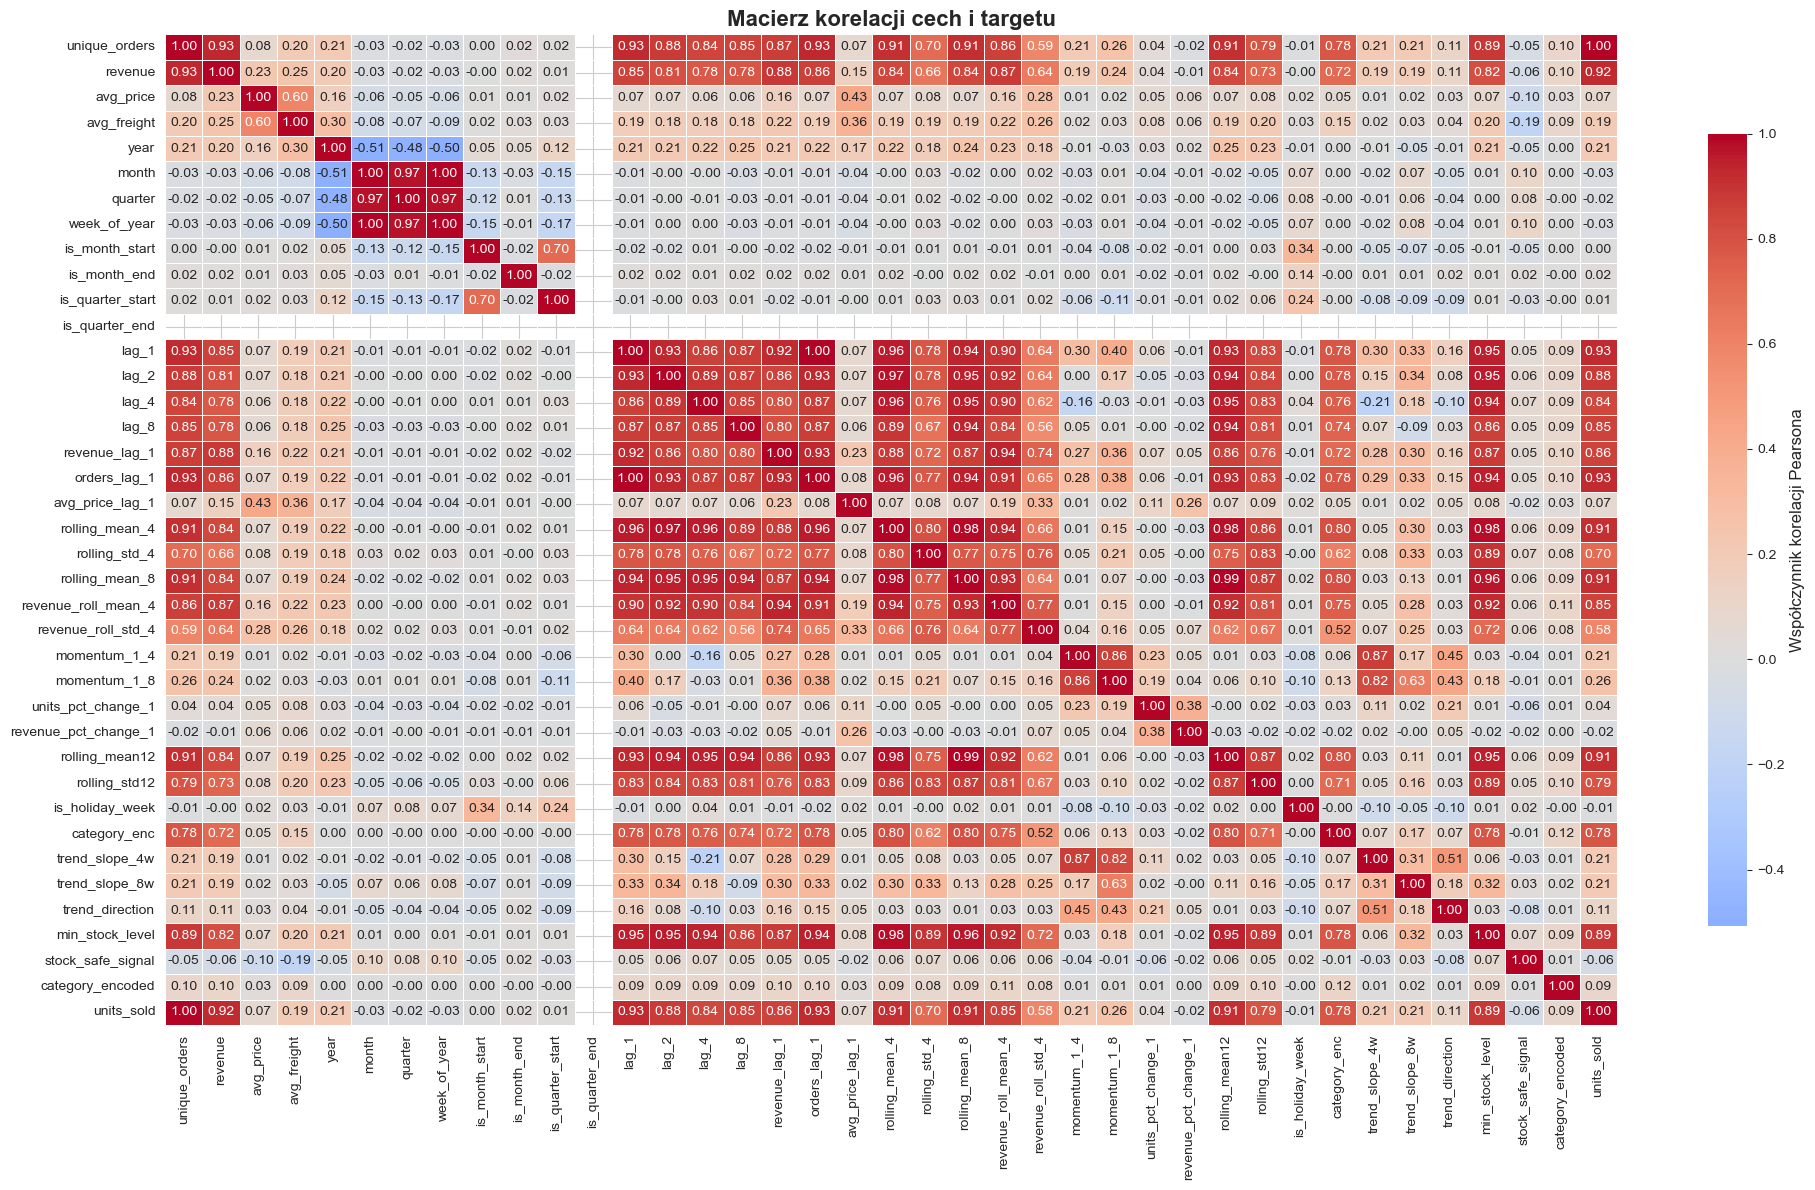

In [130]:
# 1️⃣ Ustawienie rozmiaru wykresu
plt.figure(figsize=(20, 12))  # rozmiar w calach – wystarczająco duży, by wszystko było czytelne

# 2️⃣ Obliczenie macierzy korelacji tylko dla wybranych kolumn (features + target)
corr_matrix = model_df[feature_columns + [target]].corr()

# 3️⃣ Tworzenie wykresu korelacji (heatmapy)
sns.heatmap(
    corr_matrix,
    annot=True,       # pokazuje wartości numeryczne na kaflach
    fmt=".2f",        # dwie liczby po przecinku dla czytelności
    cmap="coolwarm",  # paleta kolorów z kontrastem – przejrzysta wizualnie
    center=0,         # punkt odniesienia – środek skali kolorów
    linewidths=0.5,   # cienkie linie oddzielające kafle
    cbar_kws={"shrink": 0.8, "label": "Współczynnik korelacji Pearsona"}  # opis legendy
)

# 4️⃣ Tytuł wykresu
plt.title("Macierz korelacji cech i targetu", fontsize=16, fontweight="bold")
plt.tight_layout()  # automatyczne dopasowanie rozmieszczenia elementów
plt.show()

Modelowanie 

Model Prophet - do analizy sprzedaży stworzony przez Facebooka 

In [132]:
from prophet import Prophet
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Top 5 kategorii po łącznej sprzedaży
top5 = (
    model_df.groupby('product_category_name_english')['units_sold']
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index.tolist()
)

print("Top 5 kategorii:")
for i, cat in enumerate(top5, 1):
    print(f"  {i}. {cat}")

Top 5 kategorii:
  1. bed_bath_table
  2. health_beauty
  3. sports_leisure
  4. furniture_decor
  5. computers_accessories


trening 

In [134]:
train_cutoff = '2017-12-31'
valid_cutoff = '2018-03-31'

prophet_results = {}

In [136]:
for cat in top5:
    cat_df = (
        model_df[model_df['product_category_name_english'] == cat]
        [['purchase_week_start', 'units_sold']]
        .rename(columns={'purchase_week_start': 'ds', 'units_sold': 'y'})
        .sort_values('ds')
        .reset_index(drop=True)
    )

    # Upewnij się że ds jest datetime
    cat_df['ds'] = pd.to_datetime(cat_df['ds'])

    train = cat_df[cat_df['ds'] <= train_cutoff]
    valid = cat_df[(cat_df['ds'] > train_cutoff) & (cat_df['ds'] <= valid_cutoff)]

    m = Prophet(weekly_seasonality=False, daily_seasonality=False, yearly_seasonality=True)
    m.fit(train)

    # Predykcja - podaj daty valid wprost zamiast make_future_dataframe
    future = valid[['ds']].copy()
    forecast = m.predict(future)

    y_pred = np.maximum(forecast['yhat'].values, 0)
    y_true = valid['y'].values

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    prophet_results[cat] = {'RMSE': round(rmse, 2), 'MAE': round(mae, 2)}
    print(f"{cat:<25}  RMSE: {rmse:.2f}  MAE: {mae:.2f}")

18:54:35 - cmdstanpy - INFO - Chain [1] start processing
18:54:36 - cmdstanpy - INFO - Chain [1] done processing


bed_bath_table             RMSE: 51.28  MAE: 41.21


18:54:36 - cmdstanpy - INFO - Chain [1] start processing
18:54:37 - cmdstanpy - INFO - Chain [1] done processing


health_beauty              RMSE: 28.51  MAE: 24.82


18:54:37 - cmdstanpy - INFO - Chain [1] start processing
18:54:37 - cmdstanpy - INFO - Chain [1] done processing
18:54:38 - cmdstanpy - INFO - Chain [1] start processing


sports_leisure             RMSE: 18.23  MAE: 15.70


18:54:38 - cmdstanpy - INFO - Chain [1] done processing


furniture_decor            RMSE: 82.16  MAE: 72.65


18:54:38 - cmdstanpy - INFO - Chain [1] start processing
18:54:39 - cmdstanpy - INFO - Chain [1] done processing


computers_accessories      RMSE: 85.99  MAE: 69.95


model przewiduje w tym wypadku sztuki 
Model musi byc lepszy niż baseline wtedy jest ok , baseline przewiduje tyle co tydzien wczesniej 

In [137]:
print("\nProphet — wyniki na VALID:")
for cat, metrics in prophet_results.items():
    print(f"  {cat:<25}  RMSE: {metrics['RMSE']}  MAE: {metrics['MAE']}")


Prophet — wyniki na VALID:
  bed_bath_table             RMSE: 51.28  MAE: 41.21
  health_beauty              RMSE: 28.51  MAE: 24.82
  sports_leisure             RMSE: 18.23  MAE: 15.7
  furniture_decor            RMSE: 82.16  MAE: 72.65
  computers_accessories      RMSE: 85.99  MAE: 69.95


tabela porównawcza, dla przjezystości po każdym modelu, pierwszy porównywany z baseline 

In [138]:
# Tabela porównawcza - będziemy tu wpisywać wyniki wszystkich modeli
import pandas as pd

comparison = pd.DataFrame({
    'Model': ['Baseline', 'Prophet (avg top5)'],
    'RMSE':  [11.95, round(pd.DataFrame(prophet_results).T['RMSE'].astype(float).mean(), 2)],
    'MAE':   [5.93,  round(pd.DataFrame(prophet_results).T['MAE'].astype(float).mean(), 2)]
})

print(comparison.to_string(index=False))

             Model  RMSE   MAE
          Baseline 11.95  5.93
Prophet (avg top5) 53.23 44.87


Drugi Model RandomForest 

In [ ]:
# Usuwamy słabszy encoding bo wyszły duplikaty , a radnomforest nie może ich mieć 
 feature_columns = [col for col in feature_columns if col != 'category_encoded']

print(f"Liczba cech po usunięciu duplikatu: {len(feature_columns)}")

IndentationError: unexpected indent (4001950864.py, line 2)

In [145]:
from sklearn.ensemble import RandomForestRegressor


train_cutoff = pd.Timestamp('2017-12-31')
valid_cutoff = pd.Timestamp('2018-03-31')

train_df = model_df[model_df['purchase_week_start'] <= train_cutoff]
valid_df  = model_df[(model_df['purchase_week_start'] > train_cutoff) & 
                     (model_df['purchase_week_start'] <= valid_cutoff)]

X_train = train_df[feature_columns]
y_train = train_df['units_sold']

X_valid = valid_df[feature_columns]
y_valid = valid_df['units_sold']

print(f"Train: {X_train.shape}  |  Valid: {X_valid.shape}")

Train: (4260, 37)  |  Valid: (923, 37)


In [146]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_leaf=5,
    max_features=0.33,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
print("Trening zakończony!")

Trening zakończony!


In [147]:
y_pred_rf = np.maximum(rf_model.predict(X_valid), 0)

rmse_rf = np.sqrt(mean_squared_error(y_valid, y_pred_rf))
mae_rf  = mean_absolute_error(y_valid, y_pred_rf)

print(f"Random Forest — VALID:")
print(f"  RMSE: {rmse_rf:.2f}")
print(f"  MAE:  {mae_rf:.2f}")
print(f"\nBaseline RMSE: 11.95  →  RF RMSE: {rmse_rf:.2f}  → {'LEPIEJ' if rmse_rf < 11.95 else 'GORZEJ'}")

Random Forest — VALID:
  RMSE: 5.69
  MAE:  2.27

Baseline RMSE: 11.95  →  RF RMSE: 5.69  → LEPIEJ


In [148]:
comparison = pd.DataFrame({
    'Model': ['Baseline', 'Prophet (avg top5)', 'Random Forest'],
    'RMSE':  [11.95, 53.23, 5.69],
    'MAE':   [5.93,  44.87, 2.27]
})
print(comparison.to_string(index=False))

             Model  RMSE   MAE
          Baseline 11.95  5.93
Prophet (avg top5) 53.23 44.87
     Random Forest  5.69  2.27


różnica z czego wynika : 
Prophet   RMSE: 53.23  ← widział tylko datę
#
RF        RMSE:  5.69  ← widział 37 cech, w tym lag_1 = 0.93 korelacja

Model Trzeci XGBOOST 

import i trening 

In [149]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=500,       # 500 drzew - więcej niż RF bo XGB uczy się wolniej
    learning_rate=0.05,     # mały krok - dokładniejsze uczenie
    max_depth=6,            # głębokość drzewa
    subsample=0.8,          # 80% danych per drzewo - zapobiega overfitting
    colsample_bytree=0.8,   # 80% cech per drzewo
    min_child_weight=5,     # min obserwacji w liściu
    random_state=42,
    n_jobs=-1,
    verbosity=0             # wyłącz logi
)

xgb_model.fit(X_train, y_train)
print("Trening zakończony!")

Trening zakończony!


ocena 

In [150]:
y_pred_xgb = np.maximum(xgb_model.predict(X_valid), 0)

rmse_xgb = np.sqrt(mean_squared_error(y_valid, y_pred_xgb))
mae_xgb  = mean_absolute_error(y_valid, y_pred_xgb)

print(f"XGBoost — VALID:")
print(f"  RMSE: {rmse_xgb:.2f}")
print(f"  MAE:  {mae_xgb:.2f}")
print(f"\nRandom Forest RMSE: 5.69  →  XGB RMSE: {rmse_xgb:.2f}  → {'LEPIEJ' if rmse_xgb < 5.69 else 'GORZEJ'}")

XGBoost — VALID:
  RMSE: 5.76
  MAE:  1.98

Random Forest RMSE: 5.69  →  XGB RMSE: 5.76  → GORZEJ


poprawiamy xgboosta - szukamy najlepszych parametrów

In [151]:
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit

param_grid = {
    'n_estimators':     [300, 500, 700],
    'learning_rate':    [0.01, 0.05, 0.1],
    'max_depth':        [4, 6, 8],
    'subsample':        [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'min_child_weight': [3, 5, 10]
}

# TimeSeriesSplit - podział uwzględniający kolejność czasową
tscv = TimeSeriesSplit(n_splits=5)

xgb_search = RandomizedSearchCV(
    XGBRegressor(random_state=42, n_jobs=-1, verbosity=0),
    param_distributions=param_grid,
    n_iter=30,          # testuj 30 losowych kombinacji
    scoring='neg_root_mean_squared_error',
    cv=tscv,
    random_state=42,
    n_jobs=-1
)

xgb_search.fit(X_train, y_train)
print("Najlepsze parametry:")
print(xgb_search.best_params_)

Najlepsze parametry:
{'subsample': 0.7, 'n_estimators': 700, 'min_child_weight': 3, 'max_depth': 6, 'learning_rate': 0.01, 'colsample_bytree': 0.7}


trening z najlepszym parametrami 

In [152]:
best_params = xgb_search.best_params_

xgb_tuned = XGBRegressor(
    **best_params,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

xgb_tuned.fit(X_train, y_train)
print("Trening zakończony!")

Trening zakończony!


In [153]:
y_pred_xgb_tuned = np.maximum(xgb_tuned.predict(X_valid), 0)

rmse_xgb_tuned = np.sqrt(mean_squared_error(y_valid, y_pred_xgb_tuned))
mae_xgb_tuned  = mean_absolute_error(y_valid, y_pred_xgb_tuned)

print(f"XGBoost tuned — VALID:")
print(f"  RMSE: {rmse_xgb_tuned:.2f}")
print(f"  MAE:  {mae_xgb_tuned:.2f}")
print(f"\nRF RMSE: 5.69  |  XGB default RMSE: 5.76  →  XGB tuned RMSE: {rmse_xgb_tuned:.2f}  → {'LEPIEJ niż RF' if rmse_xgb_tuned < 5.69 else 'GORZEJ niż RF'}")

XGBoost tuned — VALID:
  RMSE: 3.68
  MAE:  1.57

RF RMSE: 5.69  |  XGB default RMSE: 5.76  →  XGB tuned RMSE: 3.68  → LEPIEJ niż RF


porównanie dotychczasowych modeli z xgboost przed poprawą parametrów i po poprawie 

In [154]:
comparison = pd.DataFrame({
    'Model': ['Baseline', 'Prophet (avg top5)', 'Random Forest', 'XGBoost (default)', 'XGBoost (tuned)'],
    'RMSE':  [11.95, 53.23, 5.69, 5.76, 3.68],
    'MAE':   [5.93,  44.87, 2.27, 1.98, 1.57]
})
print(comparison.to_string(index=False))

             Model  RMSE   MAE
          Baseline 11.95  5.93
Prophet (avg top5) 53.23 44.87
     Random Forest  5.69  2.27
 XGBoost (default)  5.76  1.98
   XGBoost (tuned)  3.68  1.57


Model czwart LightGBM 

In [155]:
from lightgbm import LGBMRegressor

lgbm_model = LGBMRegressor(
    n_estimators=700,
    learning_rate=0.01,
    max_depth=6,
    subsample=0.7,
    colsample_bytree=0.7,
    min_child_samples=20,
    num_leaves=63,          # kluczowy parametr LightGBM - max liści per drzewo
    random_state=42,
    n_jobs=-1,
    verbose=-1              # wyłącz logi
)

lgbm_model.fit(X_train, y_train)
print("Trening zakończony!")

Trening zakończony!


In [156]:
y_pred_lgbm = np.maximum(lgbm_model.predict(X_valid), 0)

rmse_lgbm = np.sqrt(mean_squared_error(y_valid, y_pred_lgbm))
mae_lgbm  = mean_absolute_error(y_valid, y_pred_lgbm)

print(f"LightGBM — VALID:")
print(f"  RMSE: {rmse_lgbm:.2f}")
print(f"  MAE:  {mae_lgbm:.2f}")
print(f"\nXGB tuned RMSE: 3.68  →  LGBM RMSE: {rmse_lgbm:.2f}  → {'LEPIEJ' if rmse_lgbm < 3.68 else 'GORZEJ'}")

LightGBM — VALID:
  RMSE: 8.34
  MAE:  2.68

XGB tuned RMSE: 3.68  →  LGBM RMSE: 8.34  → GORZEJ


teraz poprawiamy parametry 

In [157]:
from sklearn.model_selection import RandomizedSearchCV

lgbm_param_grid = {
    'n_estimators':      [300, 500, 700],
    'learning_rate':     [0.01, 0.05, 0.1],
    'max_depth':         [4, 6, 8],
    'num_leaves':        [31, 63, 127],
    'subsample':         [0.7, 0.8, 0.9],
    'colsample_bytree':  [0.7, 0.8, 0.9],
    'min_child_samples': [10, 20, 30]
}

lgbm_search = RandomizedSearchCV(
    LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1),
    param_distributions=lgbm_param_grid,
    n_iter=30,
    scoring='neg_root_mean_squared_error',
    cv=TimeSeriesSplit(n_splits=5),
    random_state=42,
    n_jobs=-1
)

lgbm_search.fit(X_train, y_train)
print("Najlepsze parametry LightGBM:")
print(lgbm_search.best_params_)

Najlepsze parametry LightGBM:
{'subsample': 0.7, 'num_leaves': 127, 'n_estimators': 300, 'min_child_samples': 10, 'max_depth': 8, 'learning_rate': 0.01, 'colsample_bytree': 0.7}


ponowny trening z lepszymi parametrami 

In [158]:
best_lgbm_params = lgbm_search.best_params_

lgbm_tuned = LGBMRegressor(
    **best_lgbm_params,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

lgbm_tuned.fit(X_train, y_train)
print("Trening zakończony!")

Trening zakończony!


In [159]:
y_pred_lgbm_tuned = np.maximum(lgbm_tuned.predict(X_valid), 0)

rmse_lgbm_tuned = np.sqrt(mean_squared_error(y_valid, y_pred_lgbm_tuned))
mae_lgbm_tuned  = mean_absolute_error(y_valid, y_pred_lgbm_tuned)

print(f"LightGBM tuned — VALID:")
print(f"  RMSE: {rmse_lgbm_tuned:.2f}")
print(f"  MAE:  {mae_lgbm_tuned:.2f}")
print(f"\nXGB tuned RMSE: 3.68  →  LGBM tuned RMSE: {rmse_lgbm_tuned:.2f}  → {'LEPIEJ' if rmse_lgbm_tuned < 3.68 else 'GORZEJ'}")

LightGBM tuned — VALID:
  RMSE: 5.64
  MAE:  2.23

XGB tuned RMSE: 3.68  →  LGBM tuned RMSE: 5.64  → GORZEJ


In [160]:
comparison = pd.DataFrame({
    'Model':  ['Baseline', 'Prophet (avg top5)', 'Random Forest',
               'XGBoost (default)', 'XGBoost (tuned)', 
               'LightGBM (default)', 'LightGBM (tuned)'],
    'RMSE':   [11.95, 53.23, 5.69, 5.76, 3.68, 8.34, 5.64],
    'MAE':    [5.93,  44.87, 2.27, 1.98, 1.57, 2.68, 2.23]
})
print(comparison.to_string(index=False))

             Model  RMSE   MAE
          Baseline 11.95  5.93
Prophet (avg top5) 53.23 44.87
     Random Forest  5.69  2.27
 XGBoost (default)  5.76  1.98
   XGBoost (tuned)  3.68  1.57
LightGBM (default)  8.34  2.68
  LightGBM (tuned)  5.64  2.23


Piąty Model - Arima/Sarima 

In [163]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings
warnings.filterwarnings('ignore')

arima_results = {}

In [165]:
for cat in top5:
    cat_df = (
        model_df[model_df['product_category_name_english'] == cat]
        [['purchase_week_start', 'units_sold']]
        .sort_values('purchase_week_start')
        .copy()
    )
    cat_df['purchase_week_start'] = pd.to_datetime(cat_df['purchase_week_start'])
    cat_df = cat_df.set_index('purchase_week_start')

    # Pełny kalendarz tygodniowy - wypełnij brakujące tygodnie zerami
    full_index = pd.date_range(
        start=cat_df.index.min(),
        end=cat_df.index.max(),
        freq='W-MON'
    )
    cat_df = cat_df.reindex(full_index, fill_value=0)

    train = cat_df[cat_df.index <= train_cutoff]
    valid = cat_df[(cat_df.index > train_cutoff) & (cat_df.index <= valid_cutoff)]

    model = SARIMAX(
        train,
        order=(1, 1, 1),
        seasonal_order=(1, 1, 1, 52),
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    fitted = model.fit(disp=False)

    y_pred = np.maximum(fitted.forecast(steps=len(valid)).values, 0)
    y_true = valid['units_sold'].values

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    arima_results[cat] = {'RMSE': round(rmse, 2), 'MAE': round(mae, 2)}
    print(f"{cat:<25}  RMSE: {rmse:.2f}  MAE: {mae:.2f}")

print("\nGotowe!")

bed_bath_table             RMSE: 54.91  MAE: 45.97
health_beauty              RMSE: 74.62  MAE: 69.01
sports_leisure             RMSE: 70.11  MAE: 64.55
furniture_decor            RMSE: 36.83  MAE: 29.92
computers_accessories      RMSE: 193.34  MAE: 184.14

Gotowe!


In [166]:
import numpy as np

sarima_avg_rmse = round(np.mean([54.91, 74.62, 70.11, 36.83, 193.34]), 2)
sarima_avg_mae  = round(np.mean([45.97, 69.01, 64.55, 29.92, 184.14]), 2)

comparison = pd.DataFrame({
    'Model':  ['Baseline', 'Prophet (avg top5)', 'SARIMA (avg top5)',
               'Random Forest', 'XGBoost (default)',
               'XGBoost (tuned)', 'LightGBM (default)', 'LightGBM (tuned)'],
    'RMSE':   [11.95, 53.23, sarima_avg_rmse, 5.69, 5.76, 3.68, 8.34, 5.64],
    'MAE':    [5.93,  44.87, sarima_avg_mae,  2.27, 1.98, 1.57, 2.68, 2.23]
})
print(comparison.to_string(index=False))

             Model  RMSE   MAE
          Baseline 11.95  5.93
Prophet (avg top5) 53.23 44.87
 SARIMA (avg top5) 85.96 78.72
     Random Forest  5.69  2.27
 XGBoost (default)  5.76  1.98
   XGBoost (tuned)  3.68  1.57
LightGBM (default)  8.34  2.68
  LightGBM (tuned)  5.64  2.23


Model sześć LSTM - sieci neuronowe 

In [169]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.preprocessing import MinMaxScaler

print(f"TensorFlow version: {tf.__version__}")

# Skalowanie cech i targetu osobno
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_valid_scaled = scaler_X.transform(X_valid)

y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))
y_valid_scaled = scaler_y.transform(y_valid.values.reshape(-1, 1))

print(f"X_train_scaled shape: {X_train_scaled.shape}")

TensorFlow version: 2.21.0
X_train_scaled shape: (4260, 37)


In [170]:
# LSTM wymaga 3D: (wiersze, kroki czasowe, cechy)
X_train_lstm = X_train_scaled.reshape(X_train_scaled.shape[0], 1, X_train_scaled.shape[1])
X_valid_lstm = X_valid_scaled.reshape(X_valid_scaled.shape[0], 1, X_valid_scaled.shape[1])

print(f"Shape dla LSTM: {X_train_lstm.shape}")
print("Format: (wiersze, kroki_czasowe, cechy)")

Shape dla LSTM: (4260, 1, 37)
Format: (wiersze, kroki_czasowe, cechy)


In [171]:
tf.random.set_seed(42)

model_lstm = Sequential([
    LSTM(64, return_sequences=True, input_shape=(1, 37)),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

model_lstm.compile(optimizer='adam', loss='mse')
model_lstm.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 1, 64)          │        26,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 39,073 (152.63 KB)

 Trainable params: 39,073 (152.63 KB)

 Non-trainable params: 0 (0.00 B)

trening 

In [172]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,           # zatrzymaj jeśli przez 10 epok brak poprawy
    restore_best_weights=True
)

history = model_lstm.fit(
    X_train_lstm, y_train_scaled,
    validation_data=(X_valid_lstm, y_valid_scaled),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

print("Trening zakończony!")

Epoch 1/100
134/134 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - loss: 0.0012 - val_loss: 6.3793e-04
Epoch 2/100
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 4.9562e-04 - val_loss: 5.4280e-04
Epoch 3/100
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 3.5739e-04 - val_loss: 5.6942e-04
Epoch 4/100
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 2.7529e-04 - val_loss: 6.8358e-04
Epoch 5/100
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 2.3329e-04 - val_loss: 7.5069e-04
Epoch 6/100
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 2.3488e-04 - val_loss: 4.8104e-04
Epoch 7/100
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 1.7084e-04 - val_loss: 3.9056e-04
Epoch 8/100
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 1.9179e-04 - val_loss: 4.4028e-04
Epoch 9/100
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 1.6995e-04 - val_loss: 8.0958e-04
Epoch 10/100
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 1.7798e-04 - val_loss: 3.3052e-04
Epoch 11/100
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/st

In [173]:
y_pred_lstm_scaled = model_lstm.predict(X_valid_lstm, verbose=0)

# Odwróć skalowanie - wróć do oryginalnych sztuk
y_pred_lstm = scaler_y.inverse_transform(y_pred_lstm_scaled).flatten()
y_pred_lstm = np.maximum(y_pred_lstm, 0)

y_true_lstm = y_valid.values

rmse_lstm = np.sqrt(mean_squared_error(y_true_lstm, y_pred_lstm))
mae_lstm  = mean_absolute_error(y_true_lstm, y_pred_lstm)

print(f"LSTM — VALID:")
print(f"  RMSE: {rmse_lstm:.2f}")
print(f"  MAE:  {mae_lstm:.2f}")
print(f"\nXGB tuned RMSE: 3.68  →  LSTM RMSE: {rmse_lstm:.2f}  → {'LEPIEJ' if rmse_lstm < 3.68 else 'GORZEJ'}")

LSTM — VALID:
  RMSE: 6.01
  MAE:  3.90

XGB tuned RMSE: 3.68  →  LSTM RMSE: 6.01  → GORZEJ


In [174]:
sarima_avg_rmse = round(np.mean([54.91, 74.62, 70.11, 36.83, 193.34]), 2)
sarima_avg_mae  = round(np.mean([45.97, 69.01, 64.55, 29.92, 184.14]), 2)

comparison = pd.DataFrame({
    'Model':  ['Baseline', 'Prophet (avg top5)', 'SARIMA (avg top5)',
               'Random Forest', 'XGBoost (default)', 'XGBoost (tuned)',
               'LightGBM (default)', 'LightGBM (tuned)', 'LSTM'],
    'RMSE':   [11.95, 53.23, sarima_avg_rmse, 5.69, 5.76, 3.68, 8.34, 5.64, 6.01],
    'MAE':    [5.93,  44.87, sarima_avg_mae,  2.27, 1.98, 1.57, 2.68, 2.23, 3.90]
})
print(comparison.to_string(index=False))

             Model  RMSE   MAE
          Baseline 11.95  5.93
Prophet (avg top5) 53.23 44.87
 SARIMA (avg top5) 85.96 78.72
     Random Forest  5.69  2.27
 XGBoost (default)  5.76  1.98
   XGBoost (tuned)  3.68  1.57
LightGBM (default)  8.34  2.68
  LightGBM (tuned)  5.64  2.23
              LSTM  6.01  3.90


sprawdzamy czy brak revenue zmieni wyniki 

In [175]:
# Sprawdź wszystkie kolumny które są pochodną units_sold
print(model_df[['units_sold', 'revenue', 'unique_orders', 
                'revenue_lag_1', 'orders_lag_1']].head())

    units_sold  revenue  unique_orders  revenue_lag_1  orders_lag_1
8          0.0      0.0            0.0            0.0           0.0
9          0.0      0.0            0.0            0.0           0.0
10         0.0      0.0            0.0            0.0           0.0
11         0.0      0.0            0.0            0.0           0.0
12         0.0      0.0            0.0            0.0           0.0


In [176]:
# Kolumny do wykluczenia jako data leakage
leakage_cols = ['revenue', 'unique_orders']

feature_columns_clean = [col for col in feature_columns if col not in leakage_cols]

print(f"Oryginalne cechy: {len(feature_columns)}")
print(f"Cechy bez leakage: {len(feature_columns_clean)}")
print(f"Usunięte: {leakage_cols}")

Oryginalne cechy: 37
Cechy bez leakage: 35
Usunięte: ['revenue', 'unique_orders']


In [177]:
X_train_clean = train_df[feature_columns_clean]
X_valid_clean = valid_df[feature_columns_clean]

xgb_clean = XGBRegressor(**best_params, random_state=42, n_jobs=-1, verbosity=0)
xgb_clean.fit(X_train_clean, y_train)

y_pred_clean = np.maximum(xgb_clean.predict(X_valid_clean), 0)
rmse_clean = np.sqrt(mean_squared_error(y_valid, y_pred_clean))
mae_clean  = mean_absolute_error(y_valid, y_pred_clean)

print(f"XGBoost BEZ leakage — VALID:")
print(f"  RMSE: {rmse_clean:.2f}")
print(f"  MAE:  {mae_clean:.2f}")
print(f"\nXGBoost z leakage RMSE: 3.68  →  bez leakage RMSE: {rmse_clean:.2f}")
print(f"Różnica: {rmse_clean - 3.68:.2f} — {'data leakage potwierdzone!' if rmse_clean > 4.5 else 'leakage minimalny'}")

XGBoost BEZ leakage — VALID:
  RMSE: 11.42
  MAE:  5.14

XGBoost z leakage RMSE: 3.68  →  bez leakage RMSE: 11.42
Różnica: 7.74 — data leakage potwierdzone!


wszystkie modele bez data leakage 

In [178]:
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

models = {
    'Random Forest':    RandomForestRegressor(
                            n_estimators=200, max_depth=15,
                            min_samples_leaf=5, max_features=0.33,
                            random_state=42, n_jobs=-1),
    'XGBoost (tuned)':  XGBRegressor(
                            **best_params,
                            random_state=42, n_jobs=-1, verbosity=0),
    'LightGBM (tuned)': LGBMRegressor(
                            **best_lgbm_params,
                            random_state=42, n_jobs=-1, verbose=-1)
}

results_clean = {}

for name, model in models.items():
    model.fit(X_train_clean, y_train)
    y_pred = np.maximum(model.predict(X_valid_clean), 0)
    rmse = np.sqrt(mean_squared_error(y_valid, y_pred))
    mae  = mean_absolute_error(y_valid, y_pred)
    results_clean[name] = {'RMSE': round(rmse, 2), 'MAE': round(mae, 2)}
    print(f"{name:<20}  RMSE: {rmse:.2f}  MAE: {mae:.2f}")

Random Forest         RMSE: 12.04  MAE: 5.23
XGBoost (tuned)       RMSE: 11.42  MAE: 5.14
LightGBM (tuned)      RMSE: 13.21  MAE: 5.74


In [179]:
comparison_clean = pd.DataFrame({
    'Model':  ['Baseline',
               'Random Forest (clean)', 
               'XGBoost tuned (clean)', 
               'LightGBM tuned (clean)'],
    'RMSE':   [11.95,
               results_clean['Random Forest']['RMSE'],
               results_clean['XGBoost (tuned)']['RMSE'],
               results_clean['LightGBM (tuned)']['RMSE']],
    'MAE':    [5.93,
               results_clean['Random Forest']['MAE'],
               results_clean['XGBoost (tuned)']['MAE'],
               results_clean['LightGBM (tuned)']['MAE']]
})
print("\nUCZCIWE WYNIKI (bez data leakage):")
print(comparison_clean.to_string(index=False))


UCZCIWE WYNIKI (bez data leakage):
                 Model  RMSE  MAE
              Baseline 11.95 5.93
 Random Forest (clean) 12.04 5.23
 XGBoost tuned (clean) 11.42 5.14
LightGBM tuned (clean) 13.21 5.74


lstm 

In [181]:
from sklearn.preprocessing import MinMaxScaler

scaler_lstm = MinMaxScaler()
X_train_s   = scaler_lstm.fit_transform(X_train_clean.fillna(0))
X_valid_s   = scaler_lstm.transform(X_valid_clean.fillna(0))

# LSTM potrzebuje 3D: (samples, timesteps, features)
X_tr_lstm = X_train_s.reshape(X_train_s.shape[0], 1, X_train_s.shape[1])
X_va_lstm = X_valid_s.reshape(X_valid_s.shape[0], 1, X_valid_s.shape[1])

print("X_tr_lstm shape:", X_tr_lstm.shape)
print("X_va_lstm shape:", X_va_lstm.shape)

X_tr_lstm shape: (4260, 1, 35)
X_va_lstm shape: (923, 1, 35)


In [182]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

tf.random.set_seed(42)

model_lstm = Sequential([
    LSTM(64, input_shape=(1, X_tr_lstm.shape[2]), return_sequences=False),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])

model_lstm.compile(optimizer='adam', loss='mse')

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model_lstm.fit(
    X_tr_lstm, y_train,
    validation_data=(X_va_lstm, y_valid),
    epochs=100,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - loss: 757.3330 - val_loss: 2235.1580
Epoch 2/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 550.8226 - val_loss: 1467.3059
Epoch 3/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 287.5831 - val_loss: 595.1914
Epoch 4/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 147.0378 - val_loss: 383.6226
Epoch 5/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 132.6976 - val_loss: 338.2607
Epoch 6/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 127.0205 - val_loss: 310.6129
Epoch 7/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 121.0000 - val_loss: 287.7592
Epoch 8/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 118.6950 - val_loss: 271.5827
Epoch 9/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 117.4150 - val_loss: 257.4150
Epoch 10/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 112.8588 - val_loss: 240.3588
Epoch 11/100
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 112.2464 - val_loss: 227.5692
Epoch 12/100
67

In [183]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

y_pred_lstm = np.maximum(model_lstm.predict(X_va_lstm).flatten(), 0)
rmse_lstm   = np.sqrt(mean_squared_error(y_valid, y_pred_lstm))
mae_lstm    = mean_absolute_error(y_valid, y_pred_lstm)

print(f"LSTM (bez leakage)  RMSE: {rmse_lstm:.2f}  MAE: {mae_lstm:.2f}")

29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step
LSTM (bez leakage)  RMSE: 11.72  MAE: 7.22


In [184]:
import pandas as pd

final_results = pd.DataFrame({
    'Model':  ['Baseline', 'XGBoost tuned (clean)', 
               'Random Forest (clean)', 'LSTM (clean)', 
               'LightGBM tuned (clean)'],
    'RMSE':   [11.95, 11.42, 12.04, 11.72, 13.21],
    'MAE':    [5.93,  5.14,  5.23,  7.22,  5.74]
}).sort_values('RMSE')

print(final_results.to_string(index=False))

                 Model  RMSE  MAE
 XGBoost tuned (clean) 11.42 5.14
          LSTM (clean) 11.72 7.22
              Baseline 11.95 5.93
 Random Forest (clean) 12.04 5.23
LightGBM tuned (clean) 13.21 5.74


1. Data leakage potrafi fałszować wyniki o 200%+ (3.68 vs 11.42)
2. Złożoność != dokładność — XGBoost pobił LSTM i LightGBM
3. Bez feature engineering modele ML ledwo biją prostą średnią
4. Wynika z tego że oczywistym wyborem jest xgboost 